[✓] Loaded  (1152×648 px)
[✓] Maze (px)  : 551 × 444 px
[✓] Maze (cm)  : 120 × 130 cm
[✓] Grid       : 4 cols × 4 rows
[✓] Cell size  : 30–35 cm  (using 32.5 cm)
[✓] Cell (px)  : 137.8 × 111.0 px/cell  (avg 124.4)
[✓] 1 px       : 0.218 cm
[✓] Skeleton   : 2,868 px
[✓] Start      : (399, 180)
[✓] Goal       : (912, 583)
[✓] BFS        : Found — 1188 nodes

[✓] Pixel→Cell conversion  (cell_px = 124.4)
    Dir      px-run   cells        cm
    ────────────────────────────────────────
    RIGHT       366 px  →     3 cells  =     97.5 cm
    BACK          1 px  →     1 cells  =     32.5 cm
    LEFT          5 px  →     1 cells  =     32.5 cm
    BACK          1 px  →     1 cells  =     32.5 cm
    LEFT        292 px  →     2 cells  =     65.0 cm
    BACK          9 px  →     1 cells  =     32.5 cm
    RIGHT       360 px  →     3 cells  =     97.5 cm
    BACK          2 px  →     1 cells  =     32.5 cm
    RIGHT         1 px  →     1 cells  =     32.5 cm
    BACK         51 px  →     1 cell

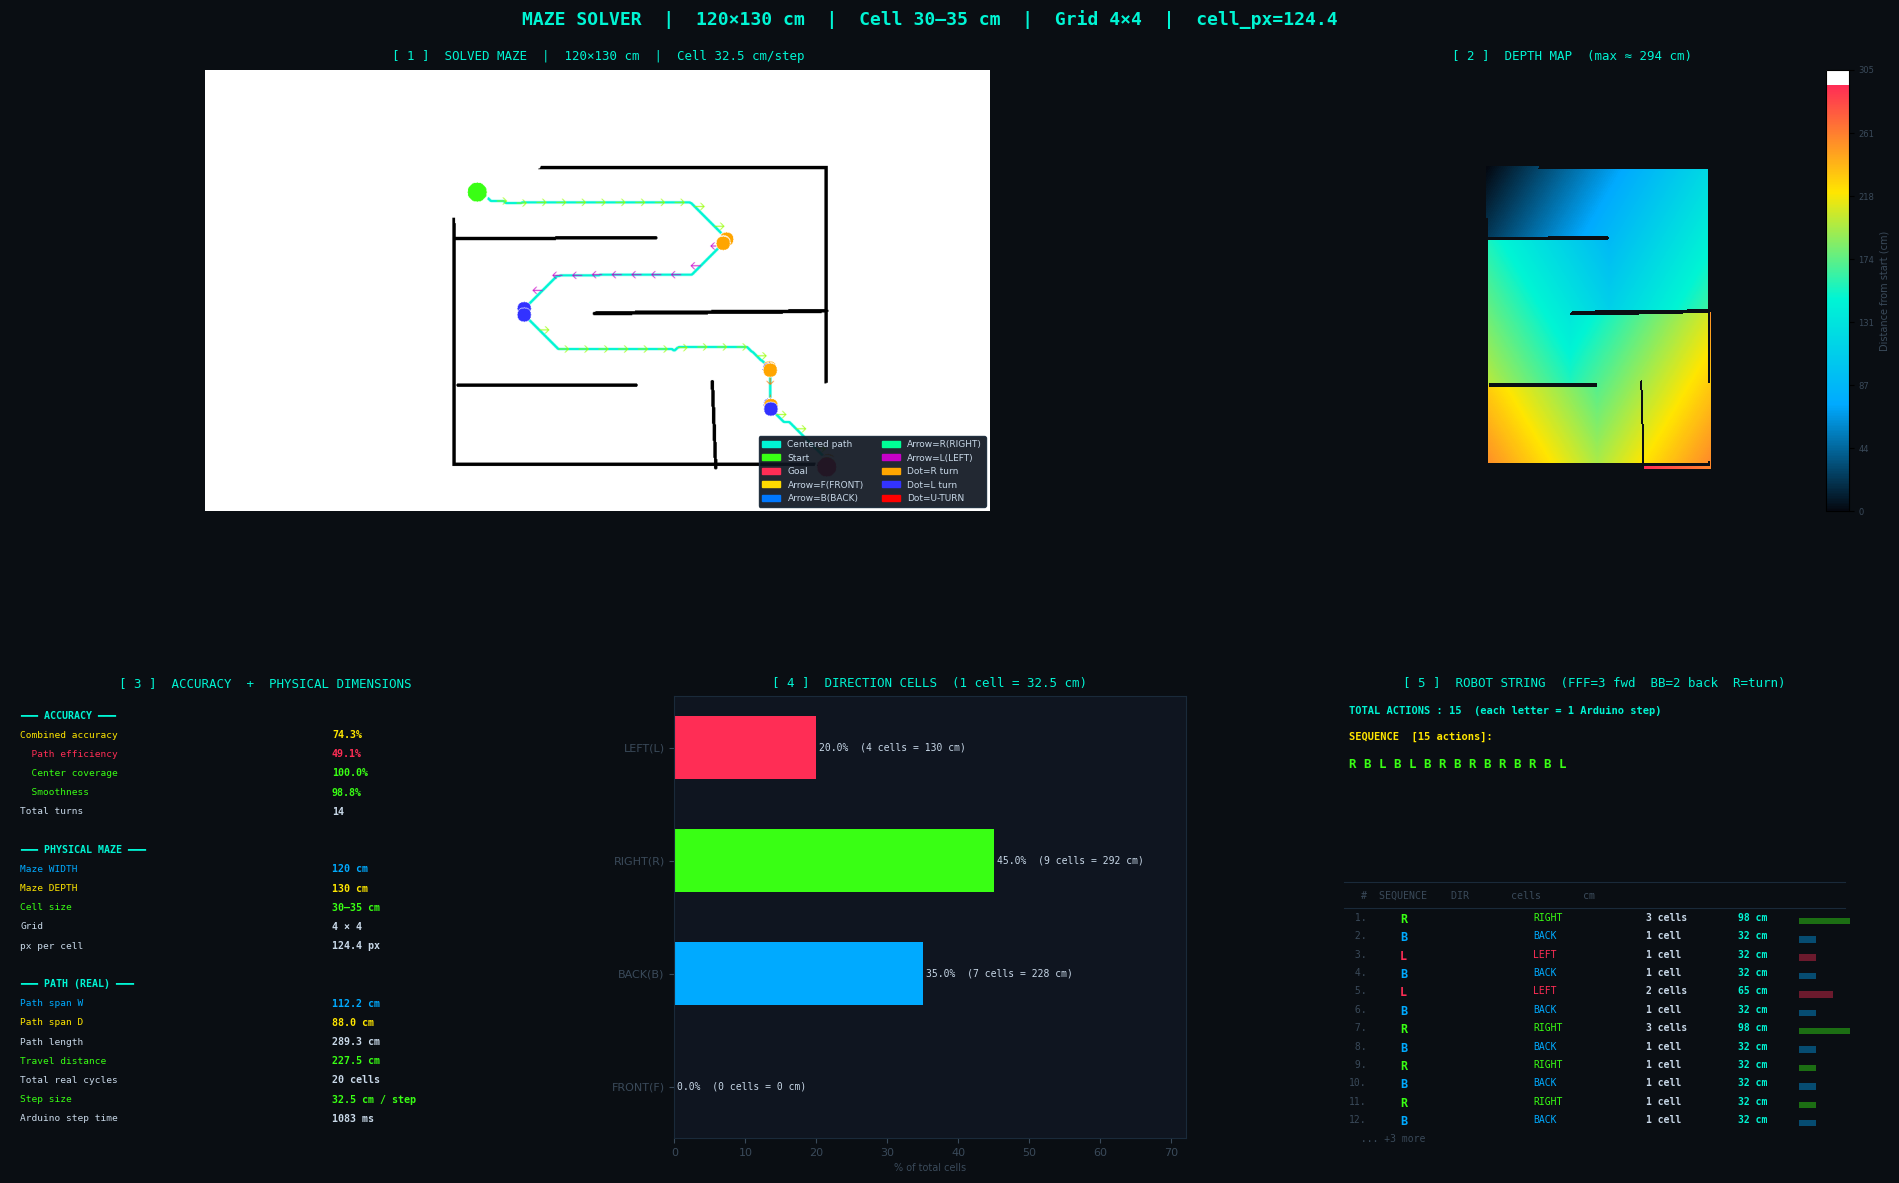


[✓] Arduino → C:\Users\Mahalakshmi\Documents\Arduino\maze_robot\maze_robot.ino
[!] Open manually: C:\Users\Mahalakshmi\Documents\Arduino\maze_robot\maze_robot.ino

   MAZE SOLVER  —  Physical 120×130 cm
   Grid           : 4 cols × 4 rows
   Cell size      : 30–35 cm  (using 32.5 cm)
   px per cell    : 124.4 px
   ─── PATH ──────────────────────────────────────────────
   Path found     : YES
   Path length    : 289.3 cm
   Travel dist    : 227.5 cm  (7 cells × 32.5 cm)
   Path span W    : 112.2 cm
   Path span D    : 88.0 cm
   Max depth      : 294 cm
   ─── ACCURACY ──────────────────────────────────────────
   Combined       : 74.3%
   ─── DIRECTION  (real cells × 32.5 cm) ────────────
     [F] FRONT       0 cells =     0.0 cm  
     [B] BACK        7 cells =   227.5 cm  ████████
     [R] RIGHT       9 cells =   292.5 cm  ███████████
     [L] LEFT        4 cells =   130.0 cm  █████
   ─── ROBOT SEQUENCE [15 actions] ─────────────────
   KEY: FFF=3 steps fwd  BB=2 steps back  R=tur

In [2]:
# ================================================================
#  MAZE SOLVER — PHYSICAL MAZE  120 cm × 130 cm
# ================================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from collections import deque
from skimage.morphology import skeletonize
import math, os, subprocess, platform, textwrap
import requests

ESP32_IP = "192.168.4.1"

# ──────────────────────────────────────────────
#  ★  PHYSICAL MAZE CONFIGURATION  ★
# ──────────────────────────────────────────────
filename        = "C:\\Users\\Mahalakshmi\\Downloads\\maze_4.png"

MAZE_REAL_W_CM  = 120.0
MAZE_REAL_D_CM  = 130.0
CELL_MIN_CM     = 30.0
CELL_MAX_CM     = 35.0
CELL_CM         = (CELL_MIN_CM + CELL_MAX_CM) / 2.0   # = 32.5 cm

ROBOT_SPEED_CM_S = 30.0
PATH_WIDTH       = 2
# ──────────────────────────────────────────────

GRID_COLS = round(MAZE_REAL_W_CM / CELL_CM)
GRID_ROWS = round(MAZE_REAL_D_CM / CELL_CM)

STEP_DURATION_MS = int(CELL_CM / ROBOT_SPEED_CM_S * 1000)

PATH_COLOR  = (0,   245, 212)
START_COLOR = (57,  255,  20)
GOAL_COLOR  = (255,  45,  85)
TURN_BGR    = {'RIGHT':(0,165,255),'LEFT':(255,50,50),'U-TURN':(0,0,255)}
DIR_ARROW   = {'N':(255,220,0),'S':(0,120,255),'E':(0,255,150),'W':(200,0,200)}

DLET = {'N':'F', 'S':'B', 'E':'R', 'W':'L'}
DSYM = {'N':'FRONT','S':'BACK','E':'RIGHT','W':'LEFT'}
DCOL = {'N':'#ffe600','S':'#0af','E':'#39ff14','W':'#ff2d55'}


# ════════════════════════════════════════════════
#  1. LOAD & THRESHOLD
# ════════════════════════════════════════════════
img = cv2.imread(filename)
if img is None:
    raise FileNotFoundError(f"Cannot open: {filename}")

img_rgb   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray      = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
H, W      = gray.shape
print(f"[✓] Loaded  ({W}×{H} px)")

_, binary = cv2.threshold(
    cv2.GaussianBlur(gray,(3,3),0), 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU)
grid = (binary > 0).astype(np.uint8)


# ════════════════════════════════════════════════
#  2. BOUNDING BOX  +  calibrate px/cell
# ════════════════════════════════════════════════
wall_rows = np.where(np.any(grid==0, axis=1))[0]
wall_cols = np.where(np.any(grid==0, axis=0))[0]
if not len(wall_rows) or not len(wall_cols):
    raise ValueError("No walls found — check image.")

box_y1, box_y2 = int(wall_rows[0]),  int(wall_rows[-1])
box_x1, box_x2 = int(wall_cols[0]),  int(wall_cols[-1])
maze_w_px = box_x2 - box_x1
maze_h_px = box_y2 - box_y1

cell_px_x = maze_w_px / GRID_COLS
cell_px_y = maze_h_px / GRID_ROWS
cell_px   = (cell_px_x + cell_px_y) / 2.0

cm_per_px = MAZE_REAL_W_CM / maze_w_px

inner = grid.copy()
inner[:box_y1,  :] = 0
inner[box_y2+1:,:] = 0
inner[:, :box_x1]  = 0
inner[:,box_x2+1:] = 0

print(f"[✓] Maze (px)  : {maze_w_px} × {maze_h_px} px")
print(f"[✓] Maze (cm)  : {MAZE_REAL_W_CM:.0f} × {MAZE_REAL_D_CM:.0f} cm")
print(f"[✓] Grid       : {GRID_COLS} cols × {GRID_ROWS} rows")
print(f"[✓] Cell size  : {CELL_MIN_CM:.0f}–{CELL_MAX_CM:.0f} cm  (using {CELL_CM:.1f} cm)")
print(f"[✓] Cell (px)  : {cell_px_x:.1f} × {cell_px_y:.1f} px/cell  (avg {cell_px:.1f})")
print(f"[✓] 1 px       : {cm_per_px:.3f} cm")


# ════════════════════════════════════════════════
#  3. SKELETON
# ════════════════════════════════════════════════
skel = skeletonize(inner.astype(bool)).astype(np.uint8)
print(f"[✓] Skeleton   : {int(skel.sum()):,} px")


# ════════════════════════════════════════════════
#  4. START & GOAL
# ════════════════════════════════════════════════
def raw_endpoints(g, x1, y1, x2, y2):
    s = e = None
    for y in range(y1, y2+1):
        for x in range(x1, x2+1):
            if g[y,x] == 1: s = (x,y); break
        if s: break
    for y in range(y2, y1-1, -1):
        for x in range(x2, x1-1, -1):
            if g[y,x] == 1: e = (x,y); break
        if e: break
    return s, e

def snap(pt, sk, r=80):
    sx, sy = pt
    y0 = max(0, sy-r);     y1 = min(sk.shape[0], sy+r+1)
    x0 = max(0, sx-r);     x1 = min(sk.shape[1], sx+r+1)
    ys, xs = np.where(sk[y0:y1, x0:x1] == 1)
    if not len(xs): return pt
    ys += y0; xs += x0
    i = np.argmin((xs-sx)**2 + (ys-sy)**2)
    return (int(xs[i]), int(ys[i]))

raw_s, raw_e = raw_endpoints(inner, box_x1, box_y1, box_x2, box_y2)
start = snap(raw_s, skel)
goal  = snap(raw_e, skel)
skel[start[1], start[0]] = 1
skel[goal[1],  goal[0]]  = 1
print(f"[✓] Start      : {start}")
print(f"[✓] Goal       : {goal}")


# ════════════════════════════════════════════════
#  5. FLOOD FILL
# ════════════════════════════════════════════════
def flood_fill(g, s):
    h, w = g.shape
    reach = np.zeros((h,w), np.uint8)
    stack = [s]
    reach[s[1], s[0]] = 1
    while stack:
        x, y = stack.pop()
        for dx, dy in [(1,0),(-1,0),(0,1),(0,-1)]:
            nx, ny = x+dx, y+dy
            if 0<=nx<w and 0<=ny<h and g[ny,nx]==1 and reach[ny,nx]==0:
                reach[ny,nx] = 1
                stack.append((nx,ny))
    return reach

reachable = flood_fill(inner, raw_s)
reach_pct = reachable.sum() / grid.size * 100


# ════════════════════════════════════════════════
#  6. BFS ON SKELETON
# ════════════════════════════════════════════════
def bfs(g, s, goal):
    h, w = g.shape
    vis  = np.zeros((h,w), bool)
    prev = {}
    q    = deque([s])
    vis[s[1], s[0]] = True
    dirs = [(1,0),(-1,0),(0,1),(0,-1),(1,1),(1,-1),(-1,1),(-1,-1)]
    while q:
        x, y = q.popleft()
        if (x,y) == goal: break
        for dx, dy in dirs:
            nx, ny = x+dx, y+dy
            if 0<=nx<w and 0<=ny<h and g[ny,nx]==1 and not vis[ny,nx]:
                vis[ny,nx] = True
                prev[(nx,ny)] = (x,y)
                q.append((nx,ny))
    if goal not in prev: return None
    path, cur = [], goal
    while cur != s:
        path.append(cur)
        cur = prev[cur]
    path.append(s)
    return path[::-1]

path = bfs(skel, start, goal)
if path is None:
    print("[!] Skeleton BFS failed → fallback")
    path = bfs(inner, raw_s, raw_e)
print(f"[✓] BFS        : {'Found — '+str(len(path))+' nodes' if path else 'NOT FOUND'}")


# ════════════════════════════════════════════════
#  7. BFS DISTANCE MAP
# ════════════════════════════════════════════════
def bfs_dist(g, s):
    h, w = g.shape
    dist = np.full((h,w), -1, np.int32)
    dist[s[1], s[0]] = 0
    q = deque([s])
    while q:
        x, y = q.popleft()
        for dx, dy in [(1,0),(-1,0),(0,1),(0,-1)]:
            nx, ny = x+dx, y+dy
            if 0<=nx<w and 0<=ny<h and g[ny,nx]==1 and dist[ny,nx]==-1:
                dist[ny,nx] = dist[y,x] + 1
                q.append((nx,ny))
    return dist

dist_map     = bfs_dist(reachable, raw_s)
max_depth_px = int(np.max(dist_map[dist_map>=0])) if np.any(dist_map>=0) else 0
max_depth_cm = max_depth_px * cm_per_px


# ════════════════════════════════════════════════
#  8. DIRECTION HELPERS
# ════════════════════════════════════════════════
def facing(dx, dy):
    if dx > 0: return 'E'
    if dx < 0: return 'W'
    if dy < 0: return 'N'
    if dy > 0: return 'S'
    return None

TMAP = {
    ('N','E'):'RIGHT', ('E','S'):'RIGHT', ('S','W'):'RIGHT', ('W','N'):'RIGHT',
    ('N','W'):'LEFT',  ('W','S'):'LEFT',  ('S','E'):'LEFT',  ('E','N'):'LEFT',
    ('N','S'):'U-TURN',('S','N'):'U-TURN',('E','W'):'U-TURN',('W','E'):'U-TURN',
}

def analyse(path):
    dc = {'UP(N)':0,'DOWN(S)':0,'RIGHT(E)':0,'LEFT(W)':0}
    tc = {'RIGHT':0,'LEFT':0,'U-TURN':0}
    te = []; se = []
    if not path or len(path) < 2: return dc, tc, te, se
    prev = None
    for i in range(1, len(path)):
        dx = path[i][0]-path[i-1][0]
        dy = path[i][1]-path[i-1][1]
        d  = facing(dx, dy)
        if not d: continue
        dc[{'N':'UP(N)','S':'DOWN(S)','E':'RIGHT(E)','W':'LEFT(W)'}[d]] += 1
        if prev and d != prev:
            t = TMAP.get((prev,d), 'UNKNOWN')
            if t in tc: tc[t] += 1
            te.append((path[i-1][0], path[i-1][1], t))
        prev = d
    step = max(1, len(path)//40)
    for i in range(0, len(path)-1, step):
        dx = path[i+1][0]-path[i][0]
        dy = path[i+1][1]-path[i][1]
        d  = facing(dx, dy)
        if d: se.append((path[i][0], path[i][1], d))
    return dc, tc, te, se

dir_counts, turn_counts, turn_events, seg_events = analyse(path)
total_px_steps = sum(dir_counts.values()) or 1


# ════════════════════════════════════════════════
#  9. PIXEL RUNS → REAL CELL STEPS
# ════════════════════════════════════════════════
def px_run_to_cells(run_px):
    return max(1, round(run_px / cell_px))

raw_instructions = []
if path and len(path) > 1:
    pd = None; run_px = 0
    for i in range(1, len(path)):
        dx = path[i][0]-path[i-1][0]
        dy = path[i][1]-path[i-1][1]
        d  = facing(dx, dy)
        if not d: continue
        if d == pd:
            run_px += 1
        else:
            if pd is not None:
                raw_instructions.append((pd, run_px))
            pd = d; run_px = 1
    if pd is not None:
        raw_instructions.append((pd, run_px))

instructions = []
for d, run_px in raw_instructions:
    real_steps = px_run_to_cells(run_px)
    instructions.append((d, real_steps, run_px))

instructions = [(d, s, rp) for d, s, rp in instructions if s > 0]

# ════════════════════════════════════════════════
#  BUILD COMPACT STRING
#
#  RULE:
#    Forward  (N) → repeat F × steps   e.g. FFF = 3 cells fwd
#    Backward (S) → repeat B × steps   e.g. BB  = 2 cells back
#    Turn Right(E)→ single R            e.g. R   (1 turn = 90°)
#    Turn Left (W)→ single L            e.g. L   (1 turn = 90°)
# ════════════════════════════════════════════════
parts = []
for d, s, rp in instructions:
    if d in ('N', 'S'):
        parts.append(DLET[d] * s)
    else:
        parts.append(DLET[d])

compact_str = ' '.join(parts)

expanded_tokens = list(compact_str.replace(' ', ''))
total_inst      = len(expanded_tokens)

instr_clean = [(d, s) for d, s, _ in instructions]

total_cells_travel = sum(s for d, s, _ in instructions if d in ('N','S'))
total_travel_cm    = total_cells_travel * CELL_CM

def plen_px(p):
    if not p: return 0.0
    return sum(math.hypot(p[i][0]-p[i-1][0], p[i][1]-p[i-1][1])
               for i in range(1, len(p)))

path_px_len    = plen_px(path)
path_length_cm = path_px_len * cm_per_px

if path:
    pxs = [p[0] for p in path]; pys = [p[1] for p in path]
    span_w_cm = (max(pxs)-min(pxs)) * cm_per_px
    span_d_cm = (max(pys)-min(pys)) * cm_per_px
else:
    span_w_cm = span_d_cm = 0.0

print(f"\n[✓] Pixel→Cell conversion  (cell_px = {cell_px:.1f})")
print(f"    {'Dir':<6} {'px-run':>8}  {'cells':>6}  {'cm':>8}")
print(f"    {'─'*40}")
for d, s, rp in instructions[:20]:
    print(f"    {DSYM[d]:<8} {rp:>6} px  →  {s:>4} cells  =  {s*CELL_CM:>7.1f} cm")
if len(instructions) > 20:
    print(f"    ... +{len(instructions)-20} more")

print(f"\n[✓] Robot Sequence String  [{total_inst} actions]:")
print(f"    {compact_str}")

# ── Arduino-style quoted display ──────────────────────────────
quoted_tokens = []
for d, s, _ in instructions:
    letter = DLET[d]
    if d in ('N', 'S'):
        quoted_tokens.extend([f'"{letter}"'] * s)   # "F","F","F" per cell
    else:
        quoted_tokens.append(f'"{letter}"')          # "R" or "L" once

quoted_str = ', '.join(quoted_tokens)
print(f"\n[✓] Arduino Array Format  [{len(quoted_tokens)} tokens]:")
print(f"    {quoted_str}")
print(f"    KEY: \"F\"=1 step fwd  \"B\"=1 step back  \"R\"=turn right  \"L\"=turn left")

# ── Print full Arduino array block ────────────────────────────
print(f"\n[✓] Arduino moveSequence[] Block:")
print(f"    const char* moveSequence[] = {{")
row_size = 8
for i in range(0, len(quoted_tokens), row_size):
    chunk = quoted_tokens[i:i+row_size]
    print(f"      {', '.join(chunk)},")
print(f"    }};")
print(f"    const int seqLength = sizeof(moveSequence) / sizeof(moveSequence[0]);")


# ════════════════════════════════════════════════
#  10. ACCURACY
# ════════════════════════════════════════════════
straight_px = math.hypot(goal[0]-start[0], goal[1]-start[1]) or 1
path_eff    = min(straight_px/path_px_len*100, 100.0) if path_px_len > 0 else 0.0

skel_on_path = sum(1 for (x,y) in path if skel[y,x]==1) if path else 0
coverage     = skel_on_path/len(path)*100 if path else 0.0

total_turns  = sum(turn_counts.values())
smoothness   = max(0.0, (1.0-total_turns/(len(path) or 1))*100)
accuracy     = 0.50*path_eff + 0.30*coverage + 0.20*smoothness

dir_cm = {}
for k, sym, d_key in [('UP(N)','FRONT','N'),('DOWN(S)','BACK','S'),
                       ('RIGHT(E)','RIGHT','E'),('LEFT(W)','LEFT','W')]:
    cells = sum(s for d,s,_ in instructions if d==d_key)
    dir_cm[k] = cells * CELL_CM

print(f"\n[✓] Accuracy   : {accuracy:.1f}%")
print(f"[✓] Travel     : {total_travel_cm:.1f} cm  ({total_cells_travel} real cells × {CELL_CM} cm)")


# ════════════════════════════════════════════════
#  11. DRAW
# ════════════════════════════════════════════════
vis_bgr = cv2.cvtColor(img_rgb.copy(), cv2.COLOR_RGB2BGR)

if path and len(path) > 1:
    pts = np.array([[p[0],p[1]] for p in path], np.int32)
    cv2.polylines(vis_bgr, [pts], False,
                  (PATH_COLOR[2],PATH_COLOR[1],PATH_COLOR[0]),
                  PATH_WIDTH, cv2.LINE_AA)

alen = max(6, W//80)
for ax_, ay_, d in seg_events:
    off = {'N':(0,-alen),'S':(0,alen),'E':(alen,0),'W':(-alen,0)}
    ex, ey = ax_+off[d][0], ay_+off[d][1]
    cv2.arrowedLine(vis_bgr, (ax_,ay_), (ex,ey),
                    DIR_ARROW[d], 1, cv2.LINE_AA, tipLength=0.5)

tr = max(4, min(10, W//80))
for tx, ty, tt in turn_events:
    col = TURN_BGR.get(tt, (180,180,180))
    cv2.circle(vis_bgr, (tx,ty), tr, col, -1)
    cv2.circle(vis_bgr, (tx,ty), tr+1, (255,255,255), 1)

mr = max(6, min(14, W//55))
cv2.circle(vis_bgr, start, mr, (START_COLOR[2],START_COLOR[1],START_COLOR[0]), -1)
cv2.circle(vis_bgr, start, mr+2, (255,255,255), 2)
cv2.circle(vis_bgr, goal,  mr, (GOAL_COLOR[2],GOAL_COLOR[1],GOAL_COLOR[0]),  -1)
cv2.circle(vis_bgr, goal,  mr+2, (255,255,255), 2)

vis_show   = cv2.cvtColor(vis_bgr, cv2.COLOR_BGR2RGB)
depth_disp = dist_map.astype(np.float32)
depth_disp[dist_map == -1] = np.nan


# ════════════════════════════════════════════════
#  12. FIGURE
# ════════════════════════════════════════════════
fig = plt.figure(figsize=(20,12), facecolor='#0a0e13')
fig.suptitle(
    f'MAZE SOLVER  |  {MAZE_REAL_W_CM:.0f}×{MAZE_REAL_D_CM:.0f} cm  '
    f'|  Cell {CELL_MIN_CM:.0f}–{CELL_MAX_CM:.0f} cm  '
    f'|  Grid {GRID_COLS}×{GRID_ROWS}  '
    f'|  cell_px={cell_px:.1f}',
    color='#00f5d4', fontsize=13, fontweight='bold',
    fontfamily='monospace', y=0.98)
gs = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.30,
                      left=0.04, right=0.96, top=0.93, bottom=0.04)

def sax(ax, t):
    ax.set_facecolor('#0f1520')
    ax.set_title(t, color='#00f5d4', fontsize=9,
                 fontfamily='monospace', pad=7)
    ax.tick_params(colors='#3a4a5a', labelsize=7)
    for sp in ax.spines.values(): sp.set_edgecolor('#1a2a3a')


# ── Panel 1 — Solved maze ──────────────────────
ax1 = fig.add_subplot(gs[0,:2])
ax1.imshow(vis_show)
sax(ax1, f'[ 1 ]  SOLVED MAZE  |  {MAZE_REAL_W_CM:.0f}×{MAZE_REAL_D_CM:.0f} cm  |  Cell {CELL_CM:.1f} cm/step')
ax1.axis('off')
leg = [
    mpatches.Patch(color=np.array(PATH_COLOR)/255,   label='Centered path'),
    mpatches.Patch(color=np.array(START_COLOR)/255,  label='Start'),
    mpatches.Patch(color=np.array(GOAL_COLOR)/255,   label='Goal'),
    mpatches.Patch(color=(1.0,0.86,0.0),  label='Arrow=F(FRONT)'),
    mpatches.Patch(color=(0.0,0.47,1.0),  label='Arrow=B(BACK)'),
    mpatches.Patch(color=(0.0,1.0,0.59),  label='Arrow=R(RIGHT)'),
    mpatches.Patch(color=(0.78,0.0,0.78), label='Arrow=L(LEFT)'),
    mpatches.Patch(color=(1.0,0.65,0.0),  label='Dot=R turn'),
    mpatches.Patch(color=(0.2,0.2,1.0),   label='Dot=L turn'),
    mpatches.Patch(color=(1.0,0.0,0.0),   label='Dot=U-TURN'),
]
ax1.legend(handles=leg, loc='lower right', fontsize=6.5,
           facecolor='#0f1520', edgecolor='#1a2a3a',
           labelcolor='#c8d8e8', framealpha=0.92, ncol=2)


# ── Panel 2 — Depth map ───────────────────────
ax2 = fig.add_subplot(gs[0,2])
cmap_d = LinearSegmentedColormap.from_list(
    'd', ['#050810','#0af','#00f5d4','#ffe600','#ff2d55'])
im2 = ax2.imshow(depth_disp, cmap=cmap_d,
                 aspect='auto', interpolation='nearest')
sax(ax2, f'[ 2 ]  DEPTH MAP  (max ≈ {max_depth_cm:.0f} cm)')
cb = plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cb.ax.tick_params(labelcolor='#3a4a5a', labelsize=6)
cb.set_label('Distance from start (cm)', color='#3a4a5a', fontsize=7)
ticks = cb.get_ticks()
cb.set_ticks(ticks)
cb.set_ticklabels([f'{t*cm_per_px:.0f}' for t in ticks])
ax2.axis('off')


# ── Panel 3 — Stats ───────────────────────────
ax3 = fig.add_subplot(gs[1,0])
ax3.set_facecolor('#0f1520'); ax3.axis('off')
sax(ax3, '[ 3 ]  ACCURACY  +  PHYSICAL DIMENSIONS')

def acolor(v):
    return '#39ff14' if v>=90 else '#ffe600' if v>=70 else '#ff2d55'

total_real_cells = sum(s for _,s,_ in instructions)

rows3 = [
    ('━━━ ACCURACY ━━━',         '',                             '#00f5d4'),
    ('Combined accuracy',        f'{accuracy:.1f}%',             acolor(accuracy)),
    ('  Path efficiency',        f'{path_eff:.1f}%',             acolor(path_eff)),
    ('  Center coverage',        f'{coverage:.1f}%',             acolor(coverage)),
    ('  Smoothness',             f'{smoothness:.1f}%',           acolor(smoothness)),
    ('Total turns',              f'{total_turns}',               '#c8d8e8'),
    ('',                         '',                             '#00f5d4'),
    ('━━━ PHYSICAL MAZE ━━━',    '',                             '#00f5d4'),
    ('Maze WIDTH',               f'{MAZE_REAL_W_CM:.0f} cm',     '#0af'),
    ('Maze DEPTH',               f'{MAZE_REAL_D_CM:.0f} cm',     '#ffe600'),
    ('Cell size',                f'{CELL_MIN_CM:.0f}–{CELL_MAX_CM:.0f} cm', '#39ff14'),
    ('Grid',                     f'{GRID_COLS} × {GRID_ROWS}',   '#c8d8e8'),
    ('px per cell',              f'{cell_px:.1f} px',            '#c8d8e8'),
    ('',                         '',                             '#00f5d4'),
    ('━━━ PATH (REAL) ━━━',      '',                             '#00f5d4'),
    ('Path span W',              f'{span_w_cm:.1f} cm',          '#0af'),
    ('Path span D',              f'{span_d_cm:.1f} cm',          '#ffe600'),
    ('Path length',              f'{path_length_cm:.1f} cm',     '#c8d8e8'),
    ('Travel distance',          f'{total_travel_cm:.1f} cm',    '#39ff14'),
    ('Total real cycles',        f'{total_real_cells} cells',    '#c8d8e8'),
    ('Step size',                f'{CELL_CM:.1f} cm / step',     '#39ff14'),
    ('Arduino step time',        f'{STEP_DURATION_MS} ms',       '#c8d8e8'),
]
n3 = len(rows3)
for i, (k, v, col) in enumerate(rows3):
    y = 1.0 - (i+1)*(1.0/(n3+1))
    hd = k.startswith('━')
    ax3.text(0.02, y, k, transform=ax3.transAxes, color=col,
             fontsize=6.8 if not hd else 7.2, fontfamily='monospace',
             va='center', fontweight='bold' if hd else 'normal')
    ax3.text(0.63, y, v, transform=ax3.transAxes, color=col,
             fontsize=7.2, fontfamily='monospace',
             va='center', fontweight='bold')


# ── Panel 4 — Direction bars ──────────────────
ax4 = fig.add_subplot(gs[1,1])
ax4.set_facecolor('#0f1520')
dlabels = ['FRONT(F)','BACK(B)','RIGHT(R)','LEFT(L)']
dkeys   = ['N','S','E','W']
dcells  = [sum(s for d,s,_ in instructions if d==k) for k in dkeys]
dtotal  = sum(dcells) or 1
dpcts   = [v/dtotal*100 for v in dcells]
dcms    = [v*CELL_CM for v in dcells]
dcols   = ['#ffe600','#0af','#39ff14','#ff2d55']
bars    = ax4.barh(dlabels, dpcts, color=dcols, height=0.55)
mx      = max(dpcts) if max(dpcts) > 0 else 1
ax4.set_xlim(0, mx*1.60)
ax4.set_xlabel('% of total cells', color='#3a4a5a', fontsize=7)
for b, p, v, c in zip(bars, dpcts, dcells, dcms):
    ax4.text(p+0.4, b.get_y()+b.get_height()/2,
             f'{p:.1f}%  ({v} cells = {c:.0f} cm)',
             va='center', color='#c8d8e8',
             fontsize=7, fontfamily='monospace')
sax(ax4, f'[ 4 ]  DIRECTION CELLS  (1 cell = {CELL_CM:.1f} cm)')
ax4.tick_params(colors='#3a4a5a', labelsize=8)
for sp in ax4.spines.values(): sp.set_edgecolor('#1a2a3a')


# ── Panel 5 — Robot string ────────────────────
ax5 = fig.add_subplot(gs[1,2])
ax5.set_facecolor('#0f1520'); ax5.axis('off')
sax(ax5, '[ 5 ]  ROBOT STRING  (FFF=3 fwd  BB=2 back  R=turn)')

ax5.text(0.02, 0.98,
         f'TOTAL ACTIONS : {total_inst}  (each letter = 1 Arduino step)',
         transform=ax5.transAxes, ha='left', va='top',
         color='#00f5d4', fontsize=7.5,
         fontfamily='monospace', fontweight='bold')

ax5.text(0.02, 0.92,
         f'SEQUENCE  [{total_inst} actions]:',
         transform=ax5.transAxes, ha='left', va='top',
         color='#ffe600', fontsize=7.5,
         fontfamily='monospace', fontweight='bold')

cpl = 30
for li, ci in enumerate(range(0, min(len(compact_str), 180), cpl)):
    ax5.text(0.02, 0.86-li*0.055, compact_str[ci:ci+cpl],
             transform=ax5.transAxes, ha='left', va='top',
             color='#39ff14', fontsize=9,
             fontfamily='monospace', fontweight='bold')

ax5.plot([0.01,0.99],[0.58,0.58],
         color='#1a2a3a', lw=0.8, transform=ax5.transAxes)

ax5.text(0.02, 0.56,
         f"{'#':>3}  {'SEQUENCE':<10}  {'DIR':<8}  {'cells':>5}  {'cm':>7}",
         transform=ax5.transAxes, ha='left', va='top',
         color='#3a4a5a', fontsize=7.2, fontfamily='monospace')
ax5.plot([0.01,0.99],[0.52,0.52],
         color='#1a2a3a', lw=0.8, transform=ax5.transAxes)

max_show = 12
rh = 0.50 / max_show
for idx, (d, s, rp) in enumerate(instructions[:max_show]):
    y      = 0.51 - idx*rh
    col    = DCOL[d]
    cm_val = s * CELL_CM

    if d in ('N', 'S'):
        seq_disp = DLET[d] * s
    else:
        seq_disp = DLET[d]

    ax5.text(0.02, y, f'{idx+1:>2}.',
             transform=ax5.transAxes,
             color='#3a4a5a', fontsize=7,
             fontfamily='monospace', va='top')
    ax5.text(0.12, y, f'{seq_disp}',
             transform=ax5.transAxes,
             color=col, fontsize=8.5,
             fontfamily='monospace', va='top', fontweight='bold')
    ax5.text(0.38, y, DSYM[d],
             transform=ax5.transAxes,
             color=col, fontsize=7,
             fontfamily='monospace', va='top')
    ax5.text(0.60, y, f'{s} cell{"s" if s>1 else ""}',
             transform=ax5.transAxes,
             color='#c8d8e8', fontsize=7,
             fontfamily='monospace', va='top', fontweight='bold')
    ax5.text(0.78, y, f'{cm_val:.0f} cm',
             transform=ax5.transAxes,
             color='#00f5d4', fontsize=7,
             fontfamily='monospace', va='top', fontweight='bold')
    if instructions:
        mr2 = max(s for _,s,_ in instructions) or 1
        ax5.barh(y-rh*0.45, min(s/mr2,1)*0.10, height=rh*0.35,
                 left=0.90, color=col, alpha=0.4,
                 transform=ax5.transAxes)

if len(instructions) > max_show:
    ax5.text(0.02, 0.51-max_show*rh,
             f'  ... +{len(instructions)-max_show} more',
             transform=ax5.transAxes,
             color='#3a4a5a', fontsize=7,
             fontfamily='monospace', va='top')

out_path = "maze_result_physical.png"
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='#0a0e13')
print(f"[✓] Saved → {out_path}")
plt.show()


# ════════════════════════════════════════════════
#  13. ARDUINO  (.ino) GENERATOR
#
#  ★ FIX: moveSequence[] entries are built as:
#     F/B → one entry PER CELL  ("F","F","F" = 3 forward cells)
#     R/L → always ONE entry    ("R" = 90° turn, never "R","R","R")
#
#  Format: "R", "F", "F", "R", "F", "R", "F", "F", "L", "F", ...
#  Each quoted letter = exactly 1 Arduino runCmd() call.
# ════════════════════════════════════════════════
def gen_arduino(instr_list, accuracy, cell_cm, step_ms, robot_speed,
                maze_w, maze_d, grid_cols, grid_rows, cell_px_val):

    cm_map = {'N':'F', 'S':'B', 'E':'R', 'W':'L'}
    nm_map = {'N':'FORWARD', 'S':'BACKWARD', 'E':'TURN_RIGHT', 'W':'TURN_LEFT'}

    # ── Build moveSequence[] entries ──────────────
    # F/B: repeat s times  → "F", "F", "F",  (3 forward cells)
    # R/L: always once     → "R",             (1 × 90° turn)
    entries = []
    for d, s, _ in instr_list:
        letter = cm_map[d]
        name   = nm_map[d]
        if d in ('N', 'S'):
            for step in range(s):
                entries.append(
                    f'  "{letter}",  '
                    f'// {name:<12} step {step+1}/{s}  =  {cell_cm:.1f} cm'
                )
        else:
            # Turn is ALWAYS one entry — no repeat
            entries.append(
                f'  "{letter}",  // {name}  (90° turn)'
            )

    # ── Human-readable compact string for comment ─
    compact_parts = []
    for d, s, _ in instr_list:
        if d in ('N','S'):
            compact_parts.append(cm_map[d] * s)   # FFF / BB
        else:
            compact_parts.append(cm_map[d])        # R / L
    compact = ' '.join(compact_parts)

    total_seq_len = len(entries)
    total_fwd_cm  = sum(s*cell_cm for d,s,_ in instr_list if d in ('N','S'))

    # ── Format entries as array rows of 8 per line ─
    # produces:  "R", "F", "F", "R", "F", "R", "F", "F",
    tokens = []
    for d, s, _ in instr_list:
        letter = cm_map[d]
        if d in ('N', 'S'):
            tokens.extend([f'"{letter}"'] * s)
        else:
            tokens.append(f'"{letter}"')

    # Chunk into rows of 8 tokens each
    row_size = 8
    array_rows = []
    for i in range(0, len(tokens), row_size):
        chunk = tokens[i:i+row_size]
        array_rows.append('  ' + ', '.join(chunk) + ',')
    array_body = '\n'.join(array_rows)

    return textwrap.dedent(f"""\
    // ============================================================
    //  MAZE ROBOT — AUTO-GENERATED
    //
    //  Physical maze  : {maze_w:.0f} cm (W)  ×  {maze_d:.0f} cm (D)
    //  Grid layout    : {grid_cols} cols × {grid_rows} rows
    //  Cell size      : {cell_cm:.1f} cm per step  ({cell_px_val:.1f} px/cell)
    //  Robot speed    : {robot_speed:.0f} cm/s  →  step = {step_ms} ms
    //  Path accuracy  : {accuracy:.1f}%
    //  Total actions  : {total_seq_len}
    //  Total travel   : {total_fwd_cm:.1f} cm  (forward/back only)
    //
    //  SEQUENCE [{total_seq_len} actions]:
    //  {compact}
    //
    //  KEY:
    //    "F" = FORWARD  1 cell = {cell_cm:.1f} cm   (repeat for distance: FFF = 3 cells)
    //    "B" = BACKWARD 1 cell = {cell_cm:.1f} cm   (repeat for distance: BB  = 2 cells)
    //    "R" = TURN RIGHT 90°  (single action — never repeated)
    //    "L" = TURN LEFT  90°  (single action — never repeated)
    //
    //  FORMAT: "R", "F", "F", "R", "F", "R", "F", "F", "L", "F", ...
    //  Each quoted token = 1 runCmd() call on the Arduino.
    //
    //  WIRING  L298N  :  IN1->25  IN2->26  IN3->27  IN4->14
    //                    ENA->32  ENB->33
    //  HC-SR04  FRONT :  TRIG->5   ECHO->18
    //           LEFT  :  TRIG->19  ECHO->21
    //           RIGHT :  TRIG->22  ECHO->23
    //           BACK  :  TRIG->12  ECHO->13
    // ============================================================

    #include <WiFi.h>
    #include <WebServer.h>

    const char* WIFI_SSID = "MazeSolver";
    const char* WIFI_PASS = "12345678";
    WebServer server(80);

    // ── Physical constants ───────────────────────────────────────
    const float CELL_CM   = {cell_cm:.1f};
    const int   STEP_MS   = {step_ms};
    const float MAZE_W_CM = {maze_w:.0f};
    const float MAZE_D_CM = {maze_d:.0f};

    // ── Motor pins ───────────────────────────────────────────────
    #define ML_A   25
    #define ML_B   26
    #define MR_A   27
    #define MR_B   14
    #define ML_PWM 32
    #define MR_PWM 33

    #define MOTOR_SPEED  185
    #define TURN_SPEED    90
    #define CELL_MS     {step_ms}
    #define TURN_MS      450

    // ── Ultrasonic pins ──────────────────────────────────────────
    #define TF  5
    #define EF 18
    #define TL 19
    #define EL 21
    #define TR 22
    #define ER 23
    #define TB 12
    #define EB 13

    #define WALL_CM  15
    #define LED       2

    // ── moveSequence[] ───────────────────────────────────────────
    // Format: "R", "F", "F", "R", "F", "R", "F", "F", "L", "F", ...
    // "F" = forward 1 cell ({cell_cm:.1f} cm)   repeat = distance
    // "B" = backward 1 cell ({cell_cm:.1f} cm)  repeat = distance
    // "R" = turn right 90°  (always single, never repeated)
    // "L" = turn left  90°  (always single, never repeated)
    const char* moveSequence[] = {{
    {array_body}
    }};
    const int seqLength = sizeof(moveSequence) / sizeof(moveSequence[0]);

    // ── Motor control ────────────────────────────────────────────
    void mStop() {{
      digitalWrite(ML_A,LOW); digitalWrite(ML_B,LOW);
      digitalWrite(MR_A,LOW); digitalWrite(MR_B,LOW);
      ledcWrite(ML_PWM,0);    ledcWrite(MR_PWM,0);
    }}
    void mFwd(int s)   {{ digitalWrite(ML_A,HIGH);digitalWrite(ML_B,LOW);
                          digitalWrite(MR_A,HIGH);digitalWrite(MR_B,LOW);
                          ledcWrite(ML_PWM,s);ledcWrite(MR_PWM,s); }}
    void mBwd(int s)   {{ digitalWrite(ML_A,LOW); digitalWrite(ML_B,HIGH);
                          digitalWrite(MR_A,LOW); digitalWrite(MR_B,HIGH);
                          ledcWrite(ML_PWM,s);ledcWrite(MR_PWM,s); }}
    void mTurnR(int s) {{ digitalWrite(ML_A,HIGH);digitalWrite(ML_B,LOW);
                          digitalWrite(MR_A,LOW); digitalWrite(MR_B,HIGH);
                          ledcWrite(ML_PWM,s);ledcWrite(MR_PWM,s); }}
    void mTurnL(int s) {{ digitalWrite(ML_A,LOW); digitalWrite(ML_B,HIGH);
                          digitalWrite(MR_A,HIGH);digitalWrite(MR_B,LOW);
                          ledcWrite(ML_PWM,s);ledcWrite(MR_PWM,s); }}

    // ── Ultrasonic ───────────────────────────────────────────────
    long pingCm(int trig, int echo) {{
      digitalWrite(trig,LOW);  delayMicroseconds(2);
      digitalWrite(trig,HIGH); delayMicroseconds(10);
      digitalWrite(trig,LOW);
      long d = pulseIn(echo,HIGH,23000UL);
      return (d==0) ? 200 : d*17L/1000L;
    }}

    // ── Move functions ───────────────────────────────────────────
    void doForward() {{
      if (pingCm(TF,EF) < WALL_CM) {{ Serial.println("BLOCKED F"); return; }}
      mFwd(MOTOR_SPEED); delay(CELL_MS); mStop();
    }}
    void doBackward() {{
      if (pingCm(TB,EB) < WALL_CM) {{ Serial.println("BLOCKED B"); return; }}
      mBwd(MOTOR_SPEED); delay(CELL_MS); mStop();
    }}
    void doRight() {{ mTurnR(TURN_SPEED); delay(TURN_MS); mStop(); }}
    void doLeft()  {{ mTurnL(TURN_SPEED); delay(TURN_MS); mStop(); }}

    // ── Execute one token ────────────────────────────────────────
    void runCmd(const char* token) {{
      String t = String(token);
      Serial.println("CMD: " + t);
      if      (t == "F")  doForward();
      else if (t == "B")  doBackward();
      else if (t == "R")  doRight();
      else if (t == "L")  doLeft();
      else if (t == "S")  mStop();
      delay(300);
    }}

    void setup() {{
      Serial.begin(115200);
      Serial.println("\\n=== Maze Robot ===");
      Serial.println("Sequence: {compact}");

      pinMode(ML_A,OUTPUT); pinMode(ML_B,OUTPUT);
      pinMode(MR_A,OUTPUT); pinMode(MR_B,OUTPUT);
      ledcAttach(ML_PWM,1000,8);
      ledcAttach(MR_PWM,1000,8);
      mStop();

      pinMode(TF,OUTPUT); pinMode(EF,INPUT);
      pinMode(TL,OUTPUT); pinMode(EL,INPUT);
      pinMode(TR,OUTPUT); pinMode(ER,INPUT);
      pinMode(TB,OUTPUT); pinMode(EB,INPUT);
      pinMode(LED,OUTPUT);

      for(int i=0;i<3;i++){{
        digitalWrite(LED,HIGH);delay(200);
        digitalWrite(LED,LOW); delay(200);
      }}

      Serial.printf("Maze   : {maze_w:.0f} x {maze_d:.0f} cm\\n");
      Serial.printf("Cell   : {cell_cm:.1f} cm / {step_ms} ms\\n");
      Serial.printf("Actions: %d\\n", seqLength);
      Serial.printf("Acc    : {accuracy:.1f}%%\\n");
      Serial.println("==================");
    }}

    void loop() {{
      static bool seqDone = false;
      if (!seqDone) {{
        seqDone = true;
        delay(2000);
        for (int i = 0; i < seqLength; i++) {{
          Serial.print("Step "); Serial.print(i+1);
          Serial.print("/"); Serial.print(seqLength);
          Serial.print("  CMD:"); Serial.println(moveSequence[i]);
          runCmd(moveSequence[i]);
        }}
        Serial.println("*** GOAL REACHED ***");
        for(int i=0;i<6;i++){{
          digitalWrite(LED,HIGH);delay(120);
          digitalWrite(LED,LOW); delay(120);
        }}
      }}
      while(true) delay(1000);
    }}
    """)


# ── Save & launch ─────────────────────────────
if instructions:
    sketch_name = "maze_robot"
    sketch_dir  = os.path.join(os.path.expanduser("~"),
                               "Documents", "Arduino", sketch_name)
    os.makedirs(sketch_dir, exist_ok=True)
    ino_path = os.path.join(sketch_dir, sketch_name + ".ino")

    with open(ino_path, 'w', encoding='utf-8') as f:
        f.write(gen_arduino(instructions, accuracy, CELL_CM,
                            STEP_DURATION_MS, ROBOT_SPEED_CM_S,
                            MAZE_REAL_W_CM, MAZE_REAL_D_CM,
                            GRID_COLS, GRID_ROWS, cell_px))
    print(f"\n[✓] Arduino → {ino_path}")

    system = platform.system()
    arduino_exe = None
    if system == "Windows":
        for c in [r"C:\Program Files\Arduino IDE\Arduino IDE.exe",
                  r"C:\Program Files (x86)\Arduino IDE\Arduino IDE.exe",
                  r"C:\Program Files\Arduino\arduino_debug.exe"]:
            if os.path.exists(c): arduino_exe = c; break
    elif system == "Darwin":
        for c in ["/Applications/Arduino IDE.app/Contents/MacOS/Arduino IDE",
                  "/Applications/Arduino.app/Contents/MacOS/Arduino"]:
            if os.path.exists(c): arduino_exe = c; break
    else:
        import shutil
        for n in ["arduino-ide","arduino"]:
            f2 = shutil.which(n)
            if f2: arduino_exe = f2; break

    if arduino_exe:
        try:
            if system == "Windows": os.startfile(ino_path)
            else: subprocess.Popen([arduino_exe, ino_path], shell=False)
            print("[✓] Arduino IDE launched")
        except Exception as ex:
            print(f"[!] Launch failed: {ex}")
    else:
        print(f"[!] Open manually: {ino_path}")
else:
    print("\n[!] No path — Arduino not generated.")


# ════════════════════════════════════════════════
#  CONSOLE SUMMARY
# ════════════════════════════════════════════════
sep = "=" * 66
print(f"\n{sep}")
print(f"   MAZE SOLVER  —  Physical {MAZE_REAL_W_CM:.0f}×{MAZE_REAL_D_CM:.0f} cm")
print(f"{sep}")
print(f"   Grid           : {GRID_COLS} cols × {GRID_ROWS} rows")
print(f"   Cell size      : {CELL_MIN_CM:.0f}–{CELL_MAX_CM:.0f} cm  (using {CELL_CM:.1f} cm)")
print(f"   px per cell    : {cell_px:.1f} px")
print(f"   ─── PATH ──────────────────────────────────────────────")
print(f"   Path found     : {'YES' if path else 'NO'}")
if path:
    print(f"   Path length    : {path_length_cm:.1f} cm")
    print(f"   Travel dist    : {total_travel_cm:.1f} cm  ({total_cells_travel} cells × {CELL_CM:.1f} cm)")
    print(f"   Path span W    : {span_w_cm:.1f} cm")
    print(f"   Path span D    : {span_d_cm:.1f} cm")
    print(f"   Max depth      : {max_depth_cm:.0f} cm")
    print(f"   ─── ACCURACY ──────────────────────────────────────────")
    print(f"   Combined       : {accuracy:.1f}%")
    print(f"   ─── DIRECTION  (real cells × {CELL_CM:.1f} cm) ────────────")
    for sym, d_key, letter in [('FRONT','N','F'),('BACK','S','B'),
                                ('RIGHT','E','R'),('LEFT','W','L')]:
        cells = sum(s for d,s,_ in instructions if d==d_key)
        pct   = cells / max(dtotal,1) * 100
        print(f"     [{letter}] {sym:<8} {cells:>4} cells = {cells*CELL_CM:>7.1f} cm  "
              f"{'█'*int(pct/4)}")
    print(f"   ─── ROBOT SEQUENCE [{total_inst} actions] ─────────────────")
    print(f"   KEY: FFF=3 steps fwd  BB=2 steps back  R=turn right  L=turn left")
    print(f"   {compact_str}")
    print(f"   ─── ARDUINO ARRAY FORMAT ──────────────────────────────")
    # Print Arduino-style array for console verification
    tokens_preview = []
    for d, s, _ in instructions:
        letter = DLET[d]
        if d in ('N', 'S'):
            tokens_preview.extend([f'"{letter}"'] * s)
        else:
            tokens_preview.append(f'"{letter}"')
    row_size = 8
    print(f"   const char* moveSequence[] = {{")
    for i in range(0, len(tokens_preview), row_size):
        chunk = tokens_preview[i:i+row_size]
        print(f"     {', '.join(chunk)},")
    print(f"   }};")
    print(f"   ─── STEP TABLE ────────────────────────────────────────")
    print(f"   {'#':>4}  {'SEQ':<8}  {'DIR':<8}  {'cells':>6}  {'cm':>8}  {'(px)':>8}")
    print(f"   {'─'*58}")
    for idx, (d, s, rp) in enumerate(instructions[:30]):
        if d in ('N','S'):
            seq_disp = DLET[d] * s
        else:
            seq_disp = DLET[d]
        print(f"   {idx+1:>4}. [{seq_disp:<6}]  {DSYM[d]:<8}  {s:>5} cells"
              f"  = {s*CELL_CM:>7.1f} cm   ({rp} px)")
    if len(instructions) > 30:
        print(f"        ... +{len(instructions)-30} more")
print(sep)



def send_to_esp32(cmd):
    try:
        cmd = cmd.replace(" ", "")   # remove spaces una
        # remove spaces

        print("\n[→] Sending to ESP32:", cmd)

        response = requests.get(
            f"http://{ESP32_IP}/cmd",
            params={"a": "cmdseq", "data": cmd},
            timeout=5
        )

        print("[✓] ESP32 Response:", response.text)

    except Exception as e:
        print("[!] Error:", e)


# SEND AFTER SOLVING
if compact_str:
    send_to_esp32(compact_str)

In [ ]:
# ================================================================
#  MAZE SOLVER — PHYSICAL MAZE  120 cm × 130 cm
# ================================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from collections import deque
from skimage.morphology import skeletonize
import math, os, subprocess, platform, textwrap
import requests

ESP32_IP = "192.168.4.1"

# ──────────────────────────────────────────────
#  ★  PHYSICAL MAZE CONFIGURATION  ★
# ──────────────────────────────────────────────
filename        = "C:\\Users\\Mahalakshmi\\Pictures\\Saved Pictures\\maze_7.jpeg"

MAZE_REAL_W_CM  = 120.0
MAZE_REAL_D_CM  = 130.0
CELL_MIN_CM     = 30.0
CELL_MAX_CM     = 35.0
CELL_CM         = (CELL_MIN_CM + CELL_MAX_CM) / 2.0   # = 32.5 cm

ROBOT_SPEED_CM_S = 30.0
PATH_WIDTH       = 2
# ──────────────────────────────────────────────

GRID_COLS = round(MAZE_REAL_W_CM / CELL_CM)
GRID_ROWS = round(MAZE_REAL_D_CM / CELL_CM)

STEP_DURATION_MS = int(CELL_CM / ROBOT_SPEED_CM_S * 1000)

PATH_COLOR  = (0,   245, 212)
START_COLOR = (57,  255,  20)
GOAL_COLOR  = (255,  45,  85)
TURN_BGR    = {'RIGHT':(0,165,255),'LEFT':(255,50,50),'U-TURN':(0,0,255)}
DIR_ARROW   = {'N':(255,220,0),'S':(0,120,255),'E':(0,255,150),'W':(200,0,200)}

DLET = {'N':'F', 'S':'B', 'E':'R', 'W':'L'}
DSYM = {'N':'FRONT','S':'BACK','E':'RIGHT','W':'LEFT'}
DCOL = {'N':'#ffe600','S':'#0af','E':'#39ff14','W':'#ff2d55'}


# ════════════════════════════════════════════════
#  1. LOAD & THRESHOLD
# ════════════════════════════════════════════════
img = cv2.imread(filename)
if img is None:
    raise FileNotFoundError(f"Cannot open: {filename}")

img_rgb   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray      = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
H, W      = gray.shape
print(f"[✓] Loaded  ({W}×{H} px)")

_, binary = cv2.threshold(
    cv2.GaussianBlur(gray,(3,3),0), 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU)
grid = (binary > 0).astype(np.uint8)


# ════════════════════════════════════════════════
#  2. BOUNDING BOX  +  calibrate px/cell
# ════════════════════════════════════════════════
wall_rows = np.where(np.any(grid==0, axis=1))[0]
wall_cols = np.where(np.any(grid==0, axis=0))[0]
if not len(wall_rows) or not len(wall_cols):
    raise ValueError("No walls found — check image.")

box_y1, box_y2 = int(wall_rows[0]),  int(wall_rows[-1])
box_x1, box_x2 = int(wall_cols[0]),  int(wall_cols[-1])
maze_w_px = box_x2 - box_x1
maze_h_px = box_y2 - box_y1

cell_px_x = maze_w_px / GRID_COLS
cell_px_y = maze_h_px / GRID_ROWS
cell_px   = (cell_px_x + cell_px_y) / 2.0

cm_per_px = MAZE_REAL_W_CM / maze_w_px

inner = grid.copy()
inner[:box_y1,  :] = 0
inner[box_y2+1:,:] = 0
inner[:, :box_x1]  = 0
inner[:,box_x2+1:] = 0

print(f"[✓] Maze (px)  : {maze_w_px} × {maze_h_px} px")
print(f"[✓] Maze (cm)  : {MAZE_REAL_W_CM:.0f} × {MAZE_REAL_D_CM:.0f} cm")
print(f"[✓] Grid       : {GRID_COLS} cols × {GRID_ROWS} rows")
print(f"[✓] Cell size  : {CELL_MIN_CM:.0f}–{CELL_MAX_CM:.0f} cm  (using {CELL_CM:.1f} cm)")
print(f"[✓] Cell (px)  : {cell_px_x:.1f} × {cell_px_y:.1f} px/cell  (avg {cell_px:.1f})")
print(f"[✓] 1 px       : {cm_per_px:.3f} cm")


# ════════════════════════════════════════════════
#  3. SKELETON
# ════════════════════════════════════════════════
skel = skeletonize(inner.astype(bool)).astype(np.uint8)
print(f"[✓] Skeleton   : {int(skel.sum()):,} px")


# ════════════════════════════════════════════════
#  4. START & GOAL
# ════════════════════════════════════════════════
def raw_endpoints(g, x1, y1, x2, y2):
    s = e = None
    for y in range(y1, y2+1):
        for x in range(x1, x2+1):
            if g[y,x] == 1: s = (x,y); break
        if s: break
    for y in range(y2, y1-1, -1):
        for x in range(x2, x1-1, -1):
            if g[y,x] == 1: e = (x,y); break
        if e: break
    return s, e

def snap(pt, sk, r=80):
    sx, sy = pt
    y0 = max(0, sy-r);     y1 = min(sk.shape[0], sy+r+1)
    x0 = max(0, sx-r);     x1 = min(sk.shape[1], sx+r+1)
    ys, xs = np.where(sk[y0:y1, x0:x1] == 1)
    if not len(xs): return pt
    ys += y0; xs += x0
    i = np.argmin((xs-sx)**2 + (ys-sy)**2)
    return (int(xs[i]), int(ys[i]))

raw_s, raw_e = raw_endpoints(inner, box_x1, box_y1, box_x2, box_y2)
start = snap(raw_s, skel)
goal  = snap(raw_e, skel)
skel[start[1], start[0]] = 1
skel[goal[1],  goal[0]]  = 1
print(f"[✓] Start      : {start}")
print(f"[✓] Goal       : {goal}")


# ════════════════════════════════════════════════
#  5. FLOOD FILL
# ════════════════════════════════════════════════
def flood_fill(g, s):
    h, w = g.shape
    reach = np.zeros((h,w), np.uint8)
    stack = [s]
    reach[s[1], s[0]] = 1
    while stack:
        x, y = stack.pop()
        for dx, dy in [(1,0),(-1,0),(0,1),(0,-1)]:
            nx, ny = x+dx, y+dy
            if 0<=nx<w and 0<=ny<h and g[ny,nx]==1 and reach[ny,nx]==0:
                reach[ny,nx] = 1
                stack.append((nx,ny))
    return reach

reachable = flood_fill(inner, raw_s)
reach_pct = reachable.sum() / grid.size * 100


# ════════════════════════════════════════════════
#  6. BFS ON SKELETON
# ════════════════════════════════════════════════
def bfs(g, s, goal):
    h, w = g.shape
    vis  = np.zeros((h,w), bool)
    prev = {}
    q    = deque([s])
    vis[s[1], s[0]] = True
    dirs = [(1,0),(-1,0),(0,1),(0,-1),(1,1),(1,-1),(-1,1),(-1,-1)]
    while q:
        x, y = q.popleft()
        if (x,y) == goal: break
        for dx, dy in dirs:
            nx, ny = x+dx, y+dy
            if 0<=nx<w and 0<=ny<h and g[ny,nx]==1 and not vis[ny,nx]:
                vis[ny,nx] = True
                prev[(nx,ny)] = (x,y)
                q.append((nx,ny))
    if goal not in prev: return None
    path, cur = [], goal
    while cur != s:
        path.append(cur)
        cur = prev[cur]
    path.append(s)
    return path[::-1]

path = bfs(skel, start, goal)
if path is None:
    print("[!] Skeleton BFS failed → fallback")
    path = bfs(inner, raw_s, raw_e)
print(f"[✓] BFS        : {'Found — '+str(len(path))+' nodes' if path else 'NOT FOUND'}")


# ════════════════════════════════════════════════
#  7. BFS DISTANCE MAP
# ════════════════════════════════════════════════
def bfs_dist(g, s):
    h, w = g.shape
    dist = np.full((h,w), -1, np.int32)
    dist[s[1], s[0]] = 0
    q = deque([s])
    while q:
        x, y = q.popleft()
        for dx, dy in [(1,0),(-1,0),(0,1),(0,-1)]:
            nx, ny = x+dx, y+dy
            if 0<=nx<w and 0<=ny<h and g[ny,nx]==1 and dist[ny,nx]==-1:
                dist[ny,nx] = dist[y,x] + 1
                q.append((nx,ny))
    return dist

dist_map     = bfs_dist(reachable, raw_s)
max_depth_px = int(np.max(dist_map[dist_map>=0])) if np.any(dist_map>=0) else 0
max_depth_cm = max_depth_px * cm_per_px


# ════════════════════════════════════════════════
#  8. DIRECTION HELPERS
# ════════════════════════════════════════════════
def facing(dx, dy):
    if dx > 0: return 'E'
    if dx < 0: return 'W'
    if dy < 0: return 'N'
    if dy > 0: return 'S'
    return None

TMAP = {
    ('N','E'):'RIGHT', ('E','S'):'RIGHT', ('S','W'):'RIGHT', ('W','N'):'RIGHT',
    ('N','W'):'LEFT',  ('W','S'):'LEFT',  ('S','E'):'LEFT',  ('E','N'):'LEFT',
    ('N','S'):'U-TURN',('S','N'):'U-TURN',('E','W'):'U-TURN',('W','E'):'U-TURN',
}

def analyse(path):
    dc = {'UP(N)':0,'DOWN(S)':0,'RIGHT(E)':0,'LEFT(W)':0}
    tc = {'RIGHT':0,'LEFT':0,'U-TURN':0}
    te = []; se = []
    if not path or len(path) < 2: return dc, tc, te, se
    prev = None
    for i in range(1, len(path)):
        dx = path[i][0]-path[i-1][0]
        dy = path[i][1]-path[i-1][1]
        d  = facing(dx, dy)
        if not d: continue
        dc[{'N':'UP(N)','S':'DOWN(S)','E':'RIGHT(E)','W':'LEFT(W)'}[d]] += 1
        if prev and d != prev:
            t = TMAP.get((prev,d), 'UNKNOWN')
            if t in tc: tc[t] += 1
            te.append((path[i-1][0], path[i-1][1], t))
        prev = d
    step = max(1, len(path)//40)
    for i in range(0, len(path)-1, step):
        dx = path[i+1][0]-path[i][0]
        dy = path[i+1][1]-path[i][1]
        d  = facing(dx, dy)
        if d: se.append((path[i][0], path[i][1], d))
    return dc, tc, te, se

dir_counts, turn_counts, turn_events, seg_events = analyse(path)
total_px_steps = sum(dir_counts.values()) or 1


# ════════════════════════════════════════════════
#  9. PIXEL RUNS → REAL CELL STEPS
# ════════════════════════════════════════════════
def px_run_to_cells(run_px):
    return max(1, round(run_px / cell_px))

raw_instructions = []
if path and len(path) > 1:
    pd = None; run_px = 0
    for i in range(1, len(path)):
        dx = path[i][0]-path[i-1][0]
        dy = path[i][1]-path[i-1][1]
        d  = facing(dx, dy)
        if not d: continue
        if d == pd:
            run_px += 1
        else:
            if pd is not None:
                raw_instructions.append((pd, run_px))
            pd = d; run_px = 1
    if pd is not None:
        raw_instructions.append((pd, run_px))

instructions = []
for d, run_px in raw_instructions:
    real_steps = px_run_to_cells(run_px)
    instructions.append((d, real_steps, run_px))

instructions = [(d, s, rp) for d, s, rp in instructions if s > 0]

# ════════════════════════════════════════════════
#  BUILD COMPACT STRING
#
#  RULE:
#    Forward  (N) → repeat F × steps   e.g. FFF = 3 cells fwd
#    Backward (S) → repeat B × steps   e.g. BB  = 2 cells back
#    Turn Right(E)→ single R            e.g. R   (1 turn = 90°)
#    Turn Left (W)→ single L            e.g. L   (1 turn = 90°)
# ════════════════════════════════════════════════
parts = []
for d, s, rp in instructions:
    if d in ('N', 'S'):
        parts.append(DLET[d] * s)
    else:
        parts.append(DLET[d])

compact_str = ' '.join(parts)

expanded_tokens = list(compact_str.replace(' ', ''))
total_inst      = len(expanded_tokens)

instr_clean = [(d, s) for d, s, _ in instructions]

total_cells_travel = sum(s for d, s, _ in instructions if d in ('N','S'))
total_travel_cm    = total_cells_travel * CELL_CM

def plen_px(p):
    if not p: return 0.0
    return sum(math.hypot(p[i][0]-p[i-1][0], p[i][1]-p[i-1][1])
               for i in range(1, len(p)))

path_px_len    = plen_px(path)
path_length_cm = path_px_len * cm_per_px

if path:
    pxs = [p[0] for p in path]; pys = [p[1] for p in path]
    span_w_cm = (max(pxs)-min(pxs)) * cm_per_px
    span_d_cm = (max(pys)-min(pys)) * cm_per_px
else:
    span_w_cm = span_d_cm = 0.0

print(f"\n[✓] Pixel→Cell conversion  (cell_px = {cell_px:.1f})")
print(f"    {'Dir':<6} {'px-run':>8}  {'cells':>6}  {'cm':>8}")
print(f"    {'─'*40}")
for d, s, rp in instructions[:20]:
    print(f"    {DSYM[d]:<8} {rp:>6} px  →  {s:>4} cells  =  {s*CELL_CM:>7.1f} cm")
if len(instructions) > 20:
    print(f"    ... +{len(instructions)-20} more")

print(f"\n[✓] Robot Sequence String  [{total_inst} actions]:")
print(f"    {compact_str}")

# ── Arduino-style quoted display ──────────────────────────────
quoted_tokens = []
for d, s, _ in instructions:
    letter = DLET[d]
    if d in ('N', 'S'):
        quoted_tokens.extend([f'"{letter}"'] * s)   # "F","F","F" per cell
    else:
        quoted_tokens.append(f'"{letter}"')          # "R" or "L" once

quoted_str = ', '.join(quoted_tokens)
print(f"\n[✓] Arduino Array Format  [{len(quoted_tokens)} tokens]:")
print(f"    {quoted_str}")
print(f"    KEY: \"F\"=1 step fwd  \"B\"=1 step back  \"R\"=turn right  \"L\"=turn left")

# ── Print full Arduino array block ────────────────────────────
print(f"\n[✓] Arduino moveSequence[] Block:")
print(f"    const char* moveSequence[] = {{")
row_size = 8
for i in range(0, len(quoted_tokens), row_size):
    chunk = quoted_tokens[i:i+row_size]
    print(f"      {', '.join(chunk)},")
print(f"    }};")
print(f"    const int seqLength = sizeof(moveSequence) / sizeof(moveSequence[0]);")


# ════════════════════════════════════════════════
#  10. ACCURACY
# ════════════════════════════════════════════════
straight_px = math.hypot(goal[0]-start[0], goal[1]-start[1]) or 1
path_eff    = min(straight_px/path_px_len*100, 100.0) if path_px_len > 0 else 0.0

skel_on_path = sum(1 for (x,y) in path if skel[y,x]==1) if path else 0
coverage     = skel_on_path/len(path)*100 if path else 0.0

total_turns  = sum(turn_counts.values())
smoothness   = max(0.0, (1.0-total_turns/(len(path) or 1))*100)
accuracy     = 0.50*path_eff + 0.30*coverage + 0.20*smoothness

dir_cm = {}
for k, sym, d_key in [('UP(N)','FRONT','N'),('DOWN(S)','BACK','S'),
                       ('RIGHT(E)','RIGHT','E'),('LEFT(W)','LEFT','W')]:
    cells = sum(s for d,s,_ in instructions if d==d_key)
    dir_cm[k] = cells * CELL_CM

print(f"\n[✓] Accuracy   : {accuracy:.1f}%")
print(f"[✓] Travel     : {total_travel_cm:.1f} cm  ({total_cells_travel} real cells × {CELL_CM} cm)")


# ════════════════════════════════════════════════
#  11. DRAW
# ════════════════════════════════════════════════
vis_bgr = cv2.cvtColor(img_rgb.copy(), cv2.COLOR_RGB2BGR)

if path and len(path) > 1:
    pts = np.array([[p[0],p[1]] for p in path], np.int32)
    cv2.polylines(vis_bgr, [pts], False,
                  (PATH_COLOR[2],PATH_COLOR[1],PATH_COLOR[0]),
                  PATH_WIDTH, cv2.LINE_AA)

alen = max(6, W//80)
for ax_, ay_, d in seg_events:
    off = {'N':(0,-alen),'S':(0,alen),'E':(alen,0),'W':(-alen,0)}
    ex, ey = ax_+off[d][0], ay_+off[d][1]
    cv2.arrowedLine(vis_bgr, (ax_,ay_), (ex,ey),
                    DIR_ARROW[d], 1, cv2.LINE_AA, tipLength=0.5)

tr = max(4, min(10, W//80))
for tx, ty, tt in turn_events:
    col = TURN_BGR.get(tt, (180,180,180))
    cv2.circle(vis_bgr, (tx,ty), tr, col, -1)
    cv2.circle(vis_bgr, (tx,ty), tr+1, (255,255,255), 1)

mr = max(6, min(14, W//55))
cv2.circle(vis_bgr, start, mr, (START_COLOR[2],START_COLOR[1],START_COLOR[0]), -1)
cv2.circle(vis_bgr, start, mr+2, (255,255,255), 2)
cv2.circle(vis_bgr, goal,  mr, (GOAL_COLOR[2],GOAL_COLOR[1],GOAL_COLOR[0]),  -1)
cv2.circle(vis_bgr, goal,  mr+2, (255,255,255), 2)

vis_show   = cv2.cvtColor(vis_bgr, cv2.COLOR_BGR2RGB)
depth_disp = dist_map.astype(np.float32)
depth_disp[dist_map == -1] = np.nan


# ════════════════════════════════════════════════
#  12. FIGURE
# ════════════════════════════════════════════════
fig = plt.figure(figsize=(20,12), facecolor='#0a0e13')
fig.suptitle(
    f'MAZE SOLVER  |  {MAZE_REAL_W_CM:.0f}×{MAZE_REAL_D_CM:.0f} cm  '
    f'|  Cell {CELL_MIN_CM:.0f}–{CELL_MAX_CM:.0f} cm  '
    f'|  Grid {GRID_COLS}×{GRID_ROWS}  '
    f'|  cell_px={cell_px:.1f}',
    color='#00f5d4', fontsize=13, fontweight='bold',
    fontfamily='monospace', y=0.98)
gs = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.30,
                      left=0.04, right=0.96, top=0.93, bottom=0.04)

def sax(ax, t):
    ax.set_facecolor('#0f1520')
    ax.set_title(t, color='#00f5d4', fontsize=9,
                 fontfamily='monospace', pad=7)
    ax.tick_params(colors='#3a4a5a', labelsize=7)
    for sp in ax.spines.values(): sp.set_edgecolor('#1a2a3a')


# ── Panel 1 — Solved maze ──────────────────────
ax1 = fig.add_subplot(gs[0,:2])
ax1.imshow(vis_show)
sax(ax1, f'[ 1 ]  SOLVED MAZE  |  {MAZE_REAL_W_CM:.0f}×{MAZE_REAL_D_CM:.0f} cm  |  Cell {CELL_CM:.1f} cm/step')
ax1.axis('off')
leg = [
    mpatches.Patch(color=np.array(PATH_COLOR)/255,   label='Centered path'),
    mpatches.Patch(color=np.array(START_COLOR)/255,  label='Start'),
    mpatches.Patch(color=np.array(GOAL_COLOR)/255,   label='Goal'),
    mpatches.Patch(color=(1.0,0.86,0.0),  label='Arrow=F(FRONT)'),
    mpatches.Patch(color=(0.0,0.47,1.0),  label='Arrow=B(BACK)'),
    mpatches.Patch(color=(0.0,1.0,0.59),  label='Arrow=R(RIGHT)'),
    mpatches.Patch(color=(0.78,0.0,0.78), label='Arrow=L(LEFT)'),
    mpatches.Patch(color=(1.0,0.65,0.0),  label='Dot=R turn'),
    mpatches.Patch(color=(0.2,0.2,1.0),   label='Dot=L turn'),
    mpatches.Patch(color=(1.0,0.0,0.0),   label='Dot=U-TURN'),
]
ax1.legend(handles=leg, loc='lower right', fontsize=6.5,
           facecolor='#0f1520', edgecolor='#1a2a3a',
           labelcolor='#c8d8e8', framealpha=0.92, ncol=2)


# ── Panel 2 — Depth map ───────────────────────
ax2 = fig.add_subplot(gs[0,2])
cmap_d = LinearSegmentedColormap.from_list(
    'd', ['#050810','#0af','#00f5d4','#ffe600','#ff2d55'])
im2 = ax2.imshow(depth_disp, cmap=cmap_d,
                 aspect='auto', interpolation='nearest')
sax(ax2, f'[ 2 ]  DEPTH MAP  (max ≈ {max_depth_cm:.0f} cm)')
cb = plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cb.ax.tick_params(labelcolor='#3a4a5a', labelsize=6)
cb.set_label('Distance from start (cm)', color='#3a4a5a', fontsize=7)
ticks = cb.get_ticks()
cb.set_ticks(ticks)
cb.set_ticklabels([f'{t*cm_per_px:.0f}' for t in ticks])
ax2.axis('off')


# ── Panel 3 — Stats ───────────────────────────
ax3 = fig.add_subplot(gs[1,0])
ax3.set_facecolor('#0f1520'); ax3.axis('off')
sax(ax3, '[ 3 ]  ACCURACY  +  PHYSICAL DIMENSIONS')

def acolor(v):
    return '#39ff14' if v>=90 else '#ffe600' if v>=70 else '#ff2d55'

total_real_cells = sum(s for _,s,_ in instructions)

rows3 = [
    ('━━━ ACCURACY ━━━',         '',                             '#00f5d4'),
    ('Combined accuracy',        f'{accuracy:.1f}%',             acolor(accuracy)),
    ('  Path efficiency',        f'{path_eff:.1f}%',             acolor(path_eff)),
    ('  Center coverage',        f'{coverage:.1f}%',             acolor(coverage)),
    ('  Smoothness',             f'{smoothness:.1f}%',           acolor(smoothness)),
    ('Total turns',              f'{total_turns}',               '#c8d8e8'),
    ('',                         '',                             '#00f5d4'),
    ('━━━ PHYSICAL MAZE ━━━',    '',                             '#00f5d4'),
    ('Maze WIDTH',               f'{MAZE_REAL_W_CM:.0f} cm',     '#0af'),
    ('Maze DEPTH',               f'{MAZE_REAL_D_CM:.0f} cm',     '#ffe600'),
    ('Cell size',                f'{CELL_MIN_CM:.0f}–{CELL_MAX_CM:.0f} cm', '#39ff14'),
    ('Grid',                     f'{GRID_COLS} × {GRID_ROWS}',   '#c8d8e8'),
    ('px per cell',              f'{cell_px:.1f} px',            '#c8d8e8'),
    ('',                         '',                             '#00f5d4'),
    ('━━━ PATH (REAL) ━━━',      '',                             '#00f5d4'),
    ('Path span W',              f'{span_w_cm:.1f} cm',          '#0af'),
    ('Path span D',              f'{span_d_cm:.1f} cm',          '#ffe600'),
    ('Path length',              f'{path_length_cm:.1f} cm',     '#c8d8e8'),
    ('Travel distance',          f'{total_travel_cm:.1f} cm',    '#39ff14'),
    ('Total real cycles',        f'{total_real_cells} cells',    '#c8d8e8'),
    ('Step size',                f'{CELL_CM:.1f} cm / step',     '#39ff14'),
    ('Arduino step time',        f'{STEP_DURATION_MS} ms',       '#c8d8e8'),
]
n3 = len(rows3)
for i, (k, v, col) in enumerate(rows3):
    y = 1.0 - (i+1)*(1.0/(n3+1))
    hd = k.startswith('━')
    ax3.text(0.02, y, k, transform=ax3.transAxes, color=col,
             fontsize=6.8 if not hd else 7.2, fontfamily='monospace',
             va='center', fontweight='bold' if hd else 'normal')
    ax3.text(0.63, y, v, transform=ax3.transAxes, color=col,
             fontsize=7.2, fontfamily='monospace',
             va='center', fontweight='bold')


# ── Panel 4 — Direction bars ──────────────────
ax4 = fig.add_subplot(gs[1,1])
ax4.set_facecolor('#0f1520')
dlabels = ['FRONT(F)','BACK(B)','RIGHT(R)','LEFT(L)']
dkeys   = ['N','S','E','W']
dcells  = [sum(s for d,s,_ in instructions if d==k) for k in dkeys]
dtotal  = sum(dcells) or 1
dpcts   = [v/dtotal*100 for v in dcells]
dcms    = [v*CELL_CM for v in dcells]
dcols   = ['#ffe600','#0af','#39ff14','#ff2d55']
bars    = ax4.barh(dlabels, dpcts, color=dcols, height=0.55)
mx      = max(dpcts) if max(dpcts) > 0 else 1
ax4.set_xlim(0, mx*1.60)
ax4.set_xlabel('% of total cells', color='#3a4a5a', fontsize=7)
for b, p, v, c in zip(bars, dpcts, dcells, dcms):
    ax4.text(p+0.4, b.get_y()+b.get_height()/2,
             f'{p:.1f}%  ({v} cells = {c:.0f} cm)',
             va='center', color='#c8d8e8',
             fontsize=7, fontfamily='monospace')
sax(ax4, f'[ 4 ]  DIRECTION CELLS  (1 cell = {CELL_CM:.1f} cm)')
ax4.tick_params(colors='#3a4a5a', labelsize=8)
for sp in ax4.spines.values(): sp.set_edgecolor('#1a2a3a')


# ── Panel 5 — Robot string ────────────────────
ax5 = fig.add_subplot(gs[1,2])
ax5.set_facecolor('#0f1520'); ax5.axis('off')
sax(ax5, '[ 5 ]  ROBOT STRING  (FFF=3 fwd  BB=2 back  R=turn)')

ax5.text(0.02, 0.98,
         f'TOTAL ACTIONS : {total_inst}  (each letter = 1 Arduino step)',
         transform=ax5.transAxes, ha='left', va='top',
         color='#00f5d4', fontsize=7.5,
         fontfamily='monospace', fontweight='bold')

ax5.text(0.02, 0.92,
         f'SEQUENCE  [{total_inst} actions]:',
         transform=ax5.transAxes, ha='left', va='top',
         color='#ffe600', fontsize=7.5,
         fontfamily='monospace', fontweight='bold')

cpl = 30
for li, ci in enumerate(range(0, min(len(compact_str), 180), cpl)):
    ax5.text(0.02, 0.86-li*0.055, compact_str[ci:ci+cpl],
             transform=ax5.transAxes, ha='left', va='top',
             color='#39ff14', fontsize=9,
             fontfamily='monospace', fontweight='bold')

ax5.plot([0.01,0.99],[0.58,0.58],
         color='#1a2a3a', lw=0.8, transform=ax5.transAxes)

ax5.text(0.02, 0.56,
         f"{'#':>3}  {'SEQUENCE':<10}  {'DIR':<8}  {'cells':>5}  {'cm':>7}",
         transform=ax5.transAxes, ha='left', va='top',
         color='#3a4a5a', fontsize=7.2, fontfamily='monospace')
ax5.plot([0.01,0.99],[0.52,0.52],
         color='#1a2a3a', lw=0.8, transform=ax5.transAxes)

max_show = 12
rh = 0.50 / max_show
for idx, (d, s, rp) in enumerate(instructions[:max_show]):
    y      = 0.51 - idx*rh
    col    = DCOL[d]
    cm_val = s * CELL_CM

    if d in ('N', 'S'):
        seq_disp = DLET[d] * s
    else:
        seq_disp = DLET[d]

    ax5.text(0.02, y, f'{idx+1:>2}.',
             transform=ax5.transAxes,
             color='#3a4a5a', fontsize=7,
             fontfamily='monospace', va='top')
    ax5.text(0.12, y, f'{seq_disp}',
             transform=ax5.transAxes,
             color=col, fontsize=8.5,
             fontfamily='monospace', va='top', fontweight='bold')
    ax5.text(0.38, y, DSYM[d],
             transform=ax5.transAxes,
             color=col, fontsize=7,
             fontfamily='monospace', va='top')
    ax5.text(0.60, y, f'{s} cell{"s" if s>1 else ""}',
             transform=ax5.transAxes,
             color='#c8d8e8', fontsize=7,
             fontfamily='monospace', va='top', fontweight='bold')
    ax5.text(0.78, y, f'{cm_val:.0f} cm',
             transform=ax5.transAxes,
             color='#00f5d4', fontsize=7,
             fontfamily='monospace', va='top', fontweight='bold')
    if instructions:
        mr2 = max(s for _,s,_ in instructions) or 1
        ax5.barh(y-rh*0.45, min(s/mr2,1)*0.10, height=rh*0.35,
                 left=0.90, color=col, alpha=0.4,
                 transform=ax5.transAxes)

if len(instructions) > max_show:
    ax5.text(0.02, 0.51-max_show*rh,
             f'  ... +{len(instructions)-max_show} more',
             transform=ax5.transAxes,
             color='#3a4a5a', fontsize=7,
             fontfamily='monospace', va='top')

out_path = "maze_result_physical.png"
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='#0a0e13')
print(f"[✓] Saved → {out_path}")
plt.show()


# ════════════════════════════════════════════════
#  13. ARDUINO  (.ino) GENERATOR
#
#  ★ FIX: moveSequence[] entries are built as:
#     F/B → one entry PER CELL  ("F","F","F" = 3 forward cells)
#     R/L → always ONE entry    ("R" = 90° turn, never "R","R","R")
#
#  Format: "R", "F", "F", "R", "F", "R", "F", "F", "L", "F", ...
#  Each quoted letter = exactly 1 Arduino runCmd() call.
# ════════════════════════════════════════════════
def gen_arduino(instr_list, accuracy, cell_cm, step_ms, robot_speed,
                maze_w, maze_d, grid_cols, grid_rows, cell_px_val):

    cm_map = {'N':'F', 'S':'B', 'E':'R', 'W':'L'}
    nm_map = {'N':'FORWARD', 'S':'BACKWARD', 'E':'TURN_RIGHT', 'W':'TURN_LEFT'}

    # ── Build moveSequence[] entries ──────────────
    # F/B: repeat s times  → "F", "F", "F",  (3 forward cells)
    # R/L: always once     → "R",             (1 × 90° turn)
    entries = []
    for d, s, _ in instr_list:
        letter = cm_map[d]
        name   = nm_map[d]
        if d in ('N', 'S'):
            for step in range(s):
                entries.append(
                    f'  "{letter}",  '
                    f'// {name:<12} step {step+1}/{s}  =  {cell_cm:.1f} cm'
                )
        else:
            # Turn is ALWAYS one entry — no repeat
            entries.append(
                f'  "{letter}",  // {name}  (90° turn)'
            )

    # ── Human-readable compact string for comment ─
    compact_parts = []
    for d, s, _ in instr_list:
        if d in ('N','S'):
            compact_parts.append(cm_map[d] * s)   # FFF / BB
        else:
            compact_parts.append(cm_map[d])        # R / L
    compact = ' '.join(compact_parts)

    total_seq_len = len(entries)
    total_fwd_cm  = sum(s*cell_cm for d,s,_ in instr_list if d in ('N','S'))

    # ── Format entries as array rows of 8 per line ─
    # produces:  "R", "F", "F", "R", "F", "R", "F", "F",
    tokens = []
    for d, s, _ in instr_list:
        letter = cm_map[d]
        if d in ('N', 'S'):
            tokens.extend([f'"{letter}"'] * s)
        else:
            tokens.append(f'"{letter}"')

    # Chunk into rows of 8 tokens each
    row_size = 8
    array_rows = []
    for i in range(0, len(tokens), row_size):
        chunk = tokens[i:i+row_size]
        array_rows.append('  ' + ', '.join(chunk) + ',')
    array_body = '\n'.join(array_rows)

    return textwrap.dedent(f"""\
    // ============================================================
    //  MAZE ROBOT — AUTO-GENERATED
    //
    //  Physical maze  : {maze_w:.0f} cm (W)  ×  {maze_d:.0f} cm (D)
    //  Grid layout    : {grid_cols} cols × {grid_rows} rows
    //  Cell size      : {cell_cm:.1f} cm per step  ({cell_px_val:.1f} px/cell)
    //  Robot speed    : {robot_speed:.0f} cm/s  →  step = {step_ms} ms
    //  Path accuracy  : {accuracy:.1f}%
    //  Total actions  : {total_seq_len}
    //  Total travel   : {total_fwd_cm:.1f} cm  (forward/back only)
    //
    //  SEQUENCE [{total_seq_len} actions]:
    //  {compact}
    //
    //  KEY:
    //    "F" = FORWARD  1 cell = {cell_cm:.1f} cm   (repeat for distance: FFF = 3 cells)
    //    "B" = BACKWARD 1 cell = {cell_cm:.1f} cm   (repeat for distance: BB  = 2 cells)
    //    "R" = TURN RIGHT 90°  (single action — never repeated)
    //    "L" = TURN LEFT  90°  (single action — never repeated)
    //
    //  FORMAT: "R", "F", "F", "R", "F", "R", "F", "F", "L", "F", ...
    //  Each quoted token = 1 runCmd() call on the Arduino.
    //
    //  WIRING  L298N  :  IN1->25  IN2->26  IN3->27  IN4->14
    //                    ENA->32  ENB->33
    //  HC-SR04  FRONT :  TRIG->5   ECHO->18
    //           LEFT  :  TRIG->19  ECHO->21
    //           RIGHT :  TRIG->22  ECHO->23
    //           BACK  :  TRIG->12  ECHO->13
    // ============================================================

    #include <WiFi.h>
    #include <WebServer.h>

    const char* WIFI_SSID = "MazeSolver";
    const char* WIFI_PASS = "12345678";
    WebServer server(80);

    // ── Physical constants ───────────────────────────────────────
    const float CELL_CM   = {cell_cm:.1f};
    const int   STEP_MS   = {step_ms};
    const float MAZE_W_CM = {maze_w:.0f};
    const float MAZE_D_CM = {maze_d:.0f};

    // ── Motor pins ───────────────────────────────────────────────
    #define ML_A   25
    #define ML_B   26
    #define MR_A   27
    #define MR_B   14
    #define ML_PWM 32
    #define MR_PWM 33

    #define MOTOR_SPEED  185
    #define TURN_SPEED    90
    #define CELL_MS     {step_ms}
    #define TURN_MS      450

    // ── Ultrasonic pins ──────────────────────────────────────────
    #define TF  5
    #define EF 18
    #define TL 19
    #define EL 21
    #define TR 22
    #define ER 23
    #define TB 12
    #define EB 13

    #define WALL_CM  15
    #define LED       2

    // ── moveSequence[] ───────────────────────────────────────────
    // Format: "R", "F", "F", "R", "F", "R", "F", "F", "L", "F", ...
    // "F" = forward 1 cell ({cell_cm:.1f} cm)   repeat = distance
    // "B" = backward 1 cell ({cell_cm:.1f} cm)  repeat = distance
    // "R" = turn right 90°  (always single, never repeated)
    // "L" = turn left  90°  (always single, never repeated)
    const char* moveSequence[] = {{
    {array_body}
    }};
    const int seqLength = sizeof(moveSequence) / sizeof(moveSequence[0]);

    // ── Motor control ────────────────────────────────────────────
    void mStop() {{
      digitalWrite(ML_A,LOW); digitalWrite(ML_B,LOW);
      digitalWrite(MR_A,LOW); digitalWrite(MR_B,LOW);
      ledcWrite(ML_PWM,0);    ledcWrite(MR_PWM,0);
    }}
    void mFwd(int s)   {{ digitalWrite(ML_A,HIGH);digitalWrite(ML_B,LOW);
                          digitalWrite(MR_A,HIGH);digitalWrite(MR_B,LOW);
                          ledcWrite(ML_PWM,s);ledcWrite(MR_PWM,s); }}
    void mBwd(int s)   {{ digitalWrite(ML_A,LOW); digitalWrite(ML_B,HIGH);
                          digitalWrite(MR_A,LOW); digitalWrite(MR_B,HIGH);
                          ledcWrite(ML_PWM,s);ledcWrite(MR_PWM,s); }}
    void mTurnR(int s) {{ digitalWrite(ML_A,HIGH);digitalWrite(ML_B,LOW);
                          digitalWrite(MR_A,LOW); digitalWrite(MR_B,HIGH);
                          ledcWrite(ML_PWM,s);ledcWrite(MR_PWM,s); }}
    void mTurnL(int s) {{ digitalWrite(ML_A,LOW); digitalWrite(ML_B,HIGH);
                          digitalWrite(MR_A,HIGH);digitalWrite(MR_B,LOW);
                          ledcWrite(ML_PWM,s);ledcWrite(MR_PWM,s); }}

    // ── Ultrasonic ───────────────────────────────────────────────
    long pingCm(int trig, int echo) {{
      digitalWrite(trig,LOW);  delayMicroseconds(2);
      digitalWrite(trig,HIGH); delayMicroseconds(10);
      digitalWrite(trig,LOW);
      long d = pulseIn(echo,HIGH,23000UL);
      return (d==0) ? 200 : d*17L/1000L;
    }}

    // ── Move functions ───────────────────────────────────────────
    void doForward() {{
      if (pingCm(TF,EF) < WALL_CM) {{ Serial.println("BLOCKED F"); return; }}
      mFwd(MOTOR_SPEED); delay(CELL_MS); mStop();
    }}
    void doBackward() {{
      if (pingCm(TB,EB) < WALL_CM) {{ Serial.println("BLOCKED B"); return; }}
      mBwd(MOTOR_SPEED); delay(CELL_MS); mStop();
    }}
    void doRight() {{ mTurnR(TURN_SPEED); delay(TURN_MS); mStop(); }}
    void doLeft()  {{ mTurnL(TURN_SPEED); delay(TURN_MS); mStop(); }}

    // ── Execute one token ────────────────────────────────────────
    void runCmd(const char* token) {{
      String t = String(token);
      Serial.println("CMD: " + t);
      if      (t == "F")  doForward();
      else if (t == "B")  doBackward();
      else if (t == "R")  doRight();
      else if (t == "L")  doLeft();
      else if (t == "S")  mStop();
      delay(300);
    }}

    void setup() {{
      Serial.begin(115200);
      Serial.println("\\n=== Maze Robot ===");
      Serial.println("Sequence: {compact}");

      pinMode(ML_A,OUTPUT); pinMode(ML_B,OUTPUT);
      pinMode(MR_A,OUTPUT); pinMode(MR_B,OUTPUT);
      ledcAttach(ML_PWM,1000,8);
      ledcAttach(MR_PWM,1000,8);
      mStop();

      pinMode(TF,OUTPUT); pinMode(EF,INPUT);
      pinMode(TL,OUTPUT); pinMode(EL,INPUT);
      pinMode(TR,OUTPUT); pinMode(ER,INPUT);
      pinMode(TB,OUTPUT); pinMode(EB,INPUT);
      pinMode(LED,OUTPUT);

      for(int i=0;i<3;i++){{
        digitalWrite(LED,HIGH);delay(200);
        digitalWrite(LED,LOW); delay(200);
      }}

      Serial.printf("Maze   : {maze_w:.0f} x {maze_d:.0f} cm\\n");
      Serial.printf("Cell   : {cell_cm:.1f} cm / {step_ms} ms\\n");
      Serial.printf("Actions: %d\\n", seqLength);
      Serial.printf("Acc    : {accuracy:.1f}%%\\n");
      Serial.println("==================");
    }}

    void loop() {{
      static bool seqDone = false;
      if (!seqDone) {{
        seqDone = true;
        delay(2000);
        for (int i = 0; i < seqLength; i++) {{
          Serial.print("Step "); Serial.print(i+1);
          Serial.print("/"); Serial.print(seqLength);
          Serial.print("  CMD:"); Serial.println(moveSequence[i]);
          runCmd(moveSequence[i]);
        }}
        Serial.println("*** GOAL REACHED ***");
        for(int i=0;i<6;i++){{
          digitalWrite(LED,HIGH);delay(120);
          digitalWrite(LED,LOW); delay(120);
        }}
      }}
      while(true) delay(1000);
    }}
    """)


# ── Save & launch ─────────────────────────────
if instructions:
    sketch_name = "maze_robot"
    sketch_dir  = os.path.join(os.path.expanduser("~"),
                               "Documents", "Arduino", sketch_name)
    os.makedirs(sketch_dir, exist_ok=True)
    ino_path = os.path.join(sketch_dir, sketch_name + ".ino")

    with open(ino_path, 'w', encoding='utf-8') as f:
        f.write(gen_arduino(instructions, accuracy, CELL_CM,
                            STEP_DURATION_MS, ROBOT_SPEED_CM_S,
                            MAZE_REAL_W_CM, MAZE_REAL_D_CM,
                            GRID_COLS, GRID_ROWS, cell_px))
    print(f"\n[✓] Arduino → {ino_path}")

    system = platform.system()
    arduino_exe = None
    if system == "Windows":
        for c in [r"C:\Program Files\Arduino IDE\Arduino IDE.exe",
                  r"C:\Program Files (x86)\Arduino IDE\Arduino IDE.exe",
                  r"C:\Program Files\Arduino\arduino_debug.exe"]:
            if os.path.exists(c): arduino_exe = c; break
    elif system == "Darwin":
        for c in ["/Applications/Arduino IDE.app/Contents/MacOS/Arduino IDE",
                  "/Applications/Arduino.app/Contents/MacOS/Arduino"]:
            if os.path.exists(c): arduino_exe = c; break
    else:
        import shutil
        for n in ["arduino-ide","arduino"]:
            f2 = shutil.which(n)
            if f2: arduino_exe = f2; break

    if arduino_exe:
        try:
            if system == "Windows": os.startfile(ino_path)
            else: subprocess.Popen([arduino_exe, ino_path], shell=False)
            print("[✓] Arduino IDE launched")
        except Exception as ex:
            print(f"[!] Launch failed: {ex}")
    else:
        print(f"[!] Open manually: {ino_path}")
else:
    print("\n[!] No path — Arduino not generated.")


# ════════════════════════════════════════════════
#  CONSOLE SUMMARY
# ════════════════════════════════════════════════
sep = "=" * 66
print(f"\n{sep}")
print(f"   MAZE SOLVER  —  Physical {MAZE_REAL_W_CM:.0f}×{MAZE_REAL_D_CM:.0f} cm")
print(f"{sep}")
print(f"   Grid           : {GRID_COLS} cols × {GRID_ROWS} rows")
print(f"   Cell size      : {CELL_MIN_CM:.0f}–{CELL_MAX_CM:.0f} cm  (using {CELL_CM:.1f} cm)")
print(f"   px per cell    : {cell_px:.1f} px")
print(f"   ─── PATH ──────────────────────────────────────────────")
print(f"   Path found     : {'YES' if path else 'NO'}")
if path:
    print(f"   Path length    : {path_length_cm:.1f} cm")
    print(f"   Travel dist    : {total_travel_cm:.1f} cm  ({total_cells_travel} cells × {CELL_CM:.1f} cm)")
    print(f"   Path span W    : {span_w_cm:.1f} cm")
    print(f"   Path span D    : {span_d_cm:.1f} cm")
    print(f"   Max depth      : {max_depth_cm:.0f} cm")
    print(f"   ─── ACCURACY ──────────────────────────────────────────")
    print(f"   Combined       : {accuracy:.1f}%")
    print(f"   ─── DIRECTION  (real cells × {CELL_CM:.1f} cm) ────────────")
    for sym, d_key, letter in [('FRONT','N','F'),('BACK','S','B'),
                                ('RIGHT','E','R'),('LEFT','W','L')]:
        cells = sum(s for d,s,_ in instructions if d==d_key)
        pct   = cells / max(dtotal,1) * 100
        print(f"     [{letter}] {sym:<8} {cells:>4} cells = {cells*CELL_CM:>7.1f} cm  "
              f"{'█'*int(pct/4)}")
    print(f"   ─── ROBOT SEQUENCE [{total_inst} actions] ─────────────────")
    print(f"   KEY: FFF=3 steps fwd  BB=2 steps back  R=turn right  L=turn left")
    print(f"   {compact_str}")
    print(f"   ─── ARDUINO ARRAY FORMAT ──────────────────────────────")
    # Print Arduino-style array for console verification
    tokens_preview = []
    for d, s, _ in instructions:
        letter = DLET[d]
        if d in ('N', 'S'):
            tokens_preview.extend([f'"{letter}"'] * s)
        else:
            tokens_preview.append(f'"{letter}"')
    row_size = 8
    print(f"   const char* moveSequence[] = {{")
    for i in range(0, len(tokens_preview), row_size):
        chunk = tokens_preview[i:i+row_size]
        print(f"     {', '.join(chunk)},")
    print(f"   }};")
    print(f"   ─── STEP TABLE ────────────────────────────────────────")
    print(f"   {'#':>4}  {'SEQ':<8}  {'DIR':<8}  {'cells':>6}  {'cm':>8}  {'(px)':>8}")
    print(f"   {'─'*58}")
    for idx, (d, s, rp) in enumerate(instructions[:30]):
        if d in ('N','S'):
            seq_disp = DLET[d] * s
        else:
            seq_disp = DLET[d]
        print(f"   {idx+1:>4}. [{seq_disp:<6}]  {DSYM[d]:<8}  {s:>5} cells"
              f"  = {s*CELL_CM:>7.1f} cm   ({rp} px)")
    if len(instructions) > 30:
        print(f"        ... +{len(instructions)-30} more")
print(sep)



def send_to_esp32(cmd):
    try:
        cmd = cmd.replace(" ", "")   # remove spaces una
        # remove spaces

        print("\n[→] Sending to ESP32:", cmd)

        response = requests.get(
            f"http://{ESP32_IP}/cmd",
            params={"a": "cmdseq", "data": cmd},
            timeout=5
        )

        print("[✓] ESP32 Response:", response.text)

    except Exception as e:
        print("[!] Error:", e)


# SEND AFTER SOLVING
if compact_str:
    send_to_esp32(compact_str)

In [ ]:
# ================================================================
#  MAZE SOLVER — PHYSICAL MAZE  120 cm × 130 cm
# ================================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from collections import deque
from skimage.morphology import skeletonize
import math, os, subprocess, platform, textwrap
import requests

ESP32_IP = "192.168.4.1"

# ──────────────────────────────────────────────
#  ★  PHYSICAL MAZE CONFIGURATION  ★
# ──────────────────────────────────────────────
filename        = "C:\\Users\\Mahalakshmi\\Downloads\\maze_5.png"

MAZE_REAL_W_CM  = 120.0
MAZE_REAL_D_CM  = 130.0
CELL_MIN_CM     = 30.0
CELL_MAX_CM     = 35.0
CELL_CM         = (CELL_MIN_CM + CELL_MAX_CM) / 2.0   # = 32.5 cm

ROBOT_SPEED_CM_S = 30.0
PATH_WIDTH       = 2
# ──────────────────────────────────────────────

GRID_COLS = round(MAZE_REAL_W_CM / CELL_CM)
GRID_ROWS = round(MAZE_REAL_D_CM / CELL_CM)

STEP_DURATION_MS = int(CELL_CM / ROBOT_SPEED_CM_S * 1000)

PATH_COLOR  = (0,   245, 212)
START_COLOR = (57,  255,  20)
GOAL_COLOR  = (255,  45,  85)
TURN_BGR    = {'RIGHT':(0,165,255),'LEFT':(255,50,50),'U-TURN':(0,0,255)}
DIR_ARROW   = {'N':(255,220,0),'S':(0,120,255),'E':(0,255,150),'W':(200,0,200)}

DLET = {'N':'F', 'S':'B', 'E':'R', 'W':'L'}
DSYM = {'N':'FRONT','S':'BACK','E':'RIGHT','W':'LEFT'}
DCOL = {'N':'#ffe600','S':'#0af','E':'#39ff14','W':'#ff2d55'}


# ════════════════════════════════════════════════
#  1. LOAD & THRESHOLD
# ════════════════════════════════════════════════
img = cv2.imread(filename)
if img is None:
    raise FileNotFoundError(f"Cannot open: {filename}")

img_rgb   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray      = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
H, W      = gray.shape
print(f"[✓] Loaded  ({W}×{H} px)")

_, binary = cv2.threshold(
    cv2.GaussianBlur(gray,(3,3),0), 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU)
grid = (binary > 0).astype(np.uint8)


# ════════════════════════════════════════════════
#  2. BOUNDING BOX  +  calibrate px/cell
# ════════════════════════════════════════════════
wall_rows = np.where(np.any(grid==0, axis=1))[0]
wall_cols = np.where(np.any(grid==0, axis=0))[0]
if not len(wall_rows) or not len(wall_cols):
    raise ValueError("No walls found — check image.")

box_y1, box_y2 = int(wall_rows[0]),  int(wall_rows[-1])
box_x1, box_x2 = int(wall_cols[0]),  int(wall_cols[-1])
maze_w_px = box_x2 - box_x1
maze_h_px = box_y2 - box_y1

cell_px_x = maze_w_px / GRID_COLS
cell_px_y = maze_h_px / GRID_ROWS
cell_px   = (cell_px_x + cell_px_y) / 2.0

cm_per_px = MAZE_REAL_W_CM / maze_w_px

inner = grid.copy()
inner[:box_y1,  :] = 0
inner[box_y2+1:,:] = 0
inner[:, :box_x1]  = 0
inner[:,box_x2+1:] = 0

print(f"[✓] Maze (px)  : {maze_w_px} × {maze_h_px} px")
print(f"[✓] Maze (cm)  : {MAZE_REAL_W_CM:.0f} × {MAZE_REAL_D_CM:.0f} cm")
print(f"[✓] Grid       : {GRID_COLS} cols × {GRID_ROWS} rows")
print(f"[✓] Cell size  : {CELL_MIN_CM:.0f}–{CELL_MAX_CM:.0f} cm  (using {CELL_CM:.1f} cm)")
print(f"[✓] Cell (px)  : {cell_px_x:.1f} × {cell_px_y:.1f} px/cell  (avg {cell_px:.1f})")
print(f"[✓] 1 px       : {cm_per_px:.3f} cm")


# ════════════════════════════════════════════════
#  3. SKELETON
# ════════════════════════════════════════════════
skel = skeletonize(inner.astype(bool)).astype(np.uint8)
print(f"[✓] Skeleton   : {int(skel.sum()):,} px")


# ════════════════════════════════════════════════
#  4. START & GOAL
# ════════════════════════════════════════════════
def raw_endpoints(g, x1, y1, x2, y2):
    s = e = None
    for y in range(y1, y2+1):
        for x in range(x1, x2+1):
            if g[y,x] == 1: s = (x,y); break
        if s: break
    for y in range(y2, y1-1, -1):
        for x in range(x2, x1-1, -1):
            if g[y,x] == 1: e = (x,y); break
        if e: break
    return s, e

def snap(pt, sk, r=80):
    sx, sy = pt
    y0 = max(0, sy-r);     y1 = min(sk.shape[0], sy+r+1)
    x0 = max(0, sx-r);     x1 = min(sk.shape[1], sx+r+1)
    ys, xs = np.where(sk[y0:y1, x0:x1] == 1)
    if not len(xs): return pt
    ys += y0; xs += x0
    i = np.argmin((xs-sx)**2 + (ys-sy)**2)
    return (int(xs[i]), int(ys[i]))

raw_s, raw_e = raw_endpoints(inner, box_x1, box_y1, box_x2, box_y2)
start = snap(raw_s, skel)
goal  = snap(raw_e, skel)
skel[start[1], start[0]] = 1
skel[goal[1],  goal[0]]  = 1
print(f"[✓] Start      : {start}")
print(f"[✓] Goal       : {goal}")


# ════════════════════════════════════════════════
#  5. FLOOD FILL
# ════════════════════════════════════════════════
def flood_fill(g, s):
    h, w = g.shape
    reach = np.zeros((h,w), np.uint8)
    stack = [s]
    reach[s[1], s[0]] = 1
    while stack:
        x, y = stack.pop()
        for dx, dy in [(1,0),(-1,0),(0,1),(0,-1)]:
            nx, ny = x+dx, y+dy
            if 0<=nx<w and 0<=ny<h and g[ny,nx]==1 and reach[ny,nx]==0:
                reach[ny,nx] = 1
                stack.append((nx,ny))
    return reach

reachable = flood_fill(inner, raw_s)
reach_pct = reachable.sum() / grid.size * 100


# ════════════════════════════════════════════════
#  6. BFS ON SKELETON
# ════════════════════════════════════════════════
def bfs(g, s, goal):
    h, w = g.shape
    vis  = np.zeros((h,w), bool)
    prev = {}
    q    = deque([s])
    vis[s[1], s[0]] = True
    dirs = [(1,0),(-1,0),(0,1),(0,-1),(1,1),(1,-1),(-1,1),(-1,-1)]
    while q:
        x, y = q.popleft()
        if (x,y) == goal: break
        for dx, dy in dirs:
            nx, ny = x+dx, y+dy
            if 0<=nx<w and 0<=ny<h and g[ny,nx]==1 and not vis[ny,nx]:
                vis[ny,nx] = True
                prev[(nx,ny)] = (x,y)
                q.append((nx,ny))
    if goal not in prev: return None
    path, cur = [], goal
    while cur != s:
        path.append(cur)
        cur = prev[cur]
    path.append(s)
    return path[::-1]

path = bfs(skel, start, goal)
if path is None:
    print("[!] Skeleton BFS failed → fallback")
    path = bfs(inner, raw_s, raw_e)
print(f"[✓] BFS        : {'Found — '+str(len(path))+' nodes' if path else 'NOT FOUND'}")


# ════════════════════════════════════════════════
#  7. BFS DISTANCE MAP
# ════════════════════════════════════════════════
def bfs_dist(g, s):
    h, w = g.shape
    dist = np.full((h,w), -1, np.int32)
    dist[s[1], s[0]] = 0
    q = deque([s])
    while q:
        x, y = q.popleft()
        for dx, dy in [(1,0),(-1,0),(0,1),(0,-1)]:
            nx, ny = x+dx, y+dy
            if 0<=nx<w and 0<=ny<h and g[ny,nx]==1 and dist[ny,nx]==-1:
                dist[ny,nx] = dist[y,x] + 1
                q.append((nx,ny))
    return dist

dist_map     = bfs_dist(reachable, raw_s)
max_depth_px = int(np.max(dist_map[dist_map>=0])) if np.any(dist_map>=0) else 0
max_depth_cm = max_depth_px * cm_per_px


# ════════════════════════════════════════════════
#  8. DIRECTION HELPERS
# ════════════════════════════════════════════════
def facing(dx, dy):
    if dx > 0: return 'E'
    if dx < 0: return 'W'
    if dy < 0: return 'N'
    if dy > 0: return 'S'
    return None

TMAP = {
    ('N','E'):'RIGHT', ('E','S'):'RIGHT', ('S','W'):'RIGHT', ('W','N'):'RIGHT',
    ('N','W'):'LEFT',  ('W','S'):'LEFT',  ('S','E'):'LEFT',  ('E','N'):'LEFT',
    ('N','S'):'U-TURN',('S','N'):'U-TURN',('E','W'):'U-TURN',('W','E'):'U-TURN',
}

def analyse(path):
    dc = {'UP(N)':0,'DOWN(S)':0,'RIGHT(E)':0,'LEFT(W)':0}
    tc = {'RIGHT':0,'LEFT':0,'U-TURN':0}
    te = []; se = []
    if not path or len(path) < 2: return dc, tc, te, se
    prev = None
    for i in range(1, len(path)):
        dx = path[i][0]-path[i-1][0]
        dy = path[i][1]-path[i-1][1]
        d  = facing(dx, dy)
        if not d: continue
        dc[{'N':'UP(N)','S':'DOWN(S)','E':'RIGHT(E)','W':'LEFT(W)'}[d]] += 1
        if prev and d != prev:
            t = TMAP.get((prev,d), 'UNKNOWN')
            if t in tc: tc[t] += 1
            te.append((path[i-1][0], path[i-1][1], t))
        prev = d
    step = max(1, len(path)//40)
    for i in range(0, len(path)-1, step):
        dx = path[i+1][0]-path[i][0]
        dy = path[i+1][1]-path[i][1]
        d  = facing(dx, dy)
        if d: se.append((path[i][0], path[i][1], d))
    return dc, tc, te, se

dir_counts, turn_counts, turn_events, seg_events = analyse(path)
total_px_steps = sum(dir_counts.values()) or 1


# ════════════════════════════════════════════════
#  9. PIXEL RUNS → REAL CELL STEPS
# ════════════════════════════════════════════════
def px_run_to_cells(run_px):
    return max(1, round(run_px / cell_px))

raw_instructions = []
if path and len(path) > 1:
    pd = None; run_px = 0
    for i in range(1, len(path)):
        dx = path[i][0]-path[i-1][0]
        dy = path[i][1]-path[i-1][1]
        d  = facing(dx, dy)
        if not d: continue
        if d == pd:
            run_px += 1
        else:
            if pd is not None:
                raw_instructions.append((pd, run_px))
            pd = d; run_px = 1
    if pd is not None:
        raw_instructions.append((pd, run_px))

instructions = []
for d, run_px in raw_instructions:
    real_steps = px_run_to_cells(run_px)
    instructions.append((d, real_steps, run_px))

instructions = [(d, s, rp) for d, s, rp in instructions if s > 0]

# ════════════════════════════════════════════════
#  BUILD COMPACT STRING
#
#  RULE:
#    Forward  (N) → repeat F × steps   e.g. FFF = 3 cells fwd
#    Backward (S) → repeat B × steps   e.g. BB  = 2 cells back
#    Turn Right(E)→ single R            e.g. R   (1 turn = 90°)
#    Turn Left (W)→ single L            e.g. L   (1 turn = 90°)
# ════════════════════════════════════════════════
parts = []
for d, s, rp in instructions:
    if d in ('N', 'S'):
        parts.append(DLET[d] * s)
    else:
        parts.append(DLET[d])

compact_str = ' '.join(parts)

expanded_tokens = list(compact_str.replace(' ', ''))
total_inst      = len(expanded_tokens)

instr_clean = [(d, s) for d, s, _ in instructions]

total_cells_travel = sum(s for d, s, _ in instructions if d in ('N','S'))
total_travel_cm    = total_cells_travel * CELL_CM

def plen_px(p):
    if not p: return 0.0
    return sum(math.hypot(p[i][0]-p[i-1][0], p[i][1]-p[i-1][1])
               for i in range(1, len(p)))

path_px_len    = plen_px(path)
path_length_cm = path_px_len * cm_per_px

if path:
    pxs = [p[0] for p in path]; pys = [p[1] for p in path]
    span_w_cm = (max(pxs)-min(pxs)) * cm_per_px
    span_d_cm = (max(pys)-min(pys)) * cm_per_px
else:
    span_w_cm = span_d_cm = 0.0

print(f"\n[✓] Pixel→Cell conversion  (cell_px = {cell_px:.1f})")
print(f"    {'Dir':<6} {'px-run':>8}  {'cells':>6}  {'cm':>8}")
print(f"    {'─'*40}")
for d, s, rp in instructions[:20]:
    print(f"    {DSYM[d]:<8} {rp:>6} px  →  {s:>4} cells  =  {s*CELL_CM:>7.1f} cm")
if len(instructions) > 20:
    print(f"    ... +{len(instructions)-20} more")

print(f"\n[✓] Robot Sequence String  [{total_inst} actions]:")
print(f"    {compact_str}")

# ── Arduino-style quoted display ──────────────────────────────
quoted_tokens = []
for d, s, _ in instructions:
    letter = DLET[d]
    if d in ('N', 'S'):
        quoted_tokens.extend([f'"{letter}"'] * s)   # "F","F","F" per cell
    else:
        quoted_tokens.append(f'"{letter}"')          # "R" or "L" once

quoted_str = ', '.join(quoted_tokens)
print(f"\n[✓] Arduino Array Format  [{len(quoted_tokens)} tokens]:")
print(f"    {quoted_str}")
print(f"    KEY: \"F\"=1 step fwd  \"B\"=1 step back  \"R\"=turn right  \"L\"=turn left")

# ── Print full Arduino array block ────────────────────────────
print(f"\n[✓] Arduino moveSequence[] Block:")
print(f"    const char* moveSequence[] = {{")
row_size = 8
for i in range(0, len(quoted_tokens), row_size):
    chunk = quoted_tokens[i:i+row_size]
    print(f"      {', '.join(chunk)},")
print(f"    }};")
print(f"    const int seqLength = sizeof(moveSequence) / sizeof(moveSequence[0]);")


# ════════════════════════════════════════════════
#  10. ACCURACY
# ════════════════════════════════════════════════
straight_px = math.hypot(goal[0]-start[0], goal[1]-start[1]) or 1
path_eff    = min(straight_px/path_px_len*100, 100.0) if path_px_len > 0 else 0.0

skel_on_path = sum(1 for (x,y) in path if skel[y,x]==1) if path else 0
coverage     = skel_on_path/len(path)*100 if path else 0.0

total_turns  = sum(turn_counts.values())
smoothness   = max(0.0, (1.0-total_turns/(len(path) or 1))*100)
accuracy     = 0.50*path_eff + 0.30*coverage + 0.20*smoothness

dir_cm = {}
for k, sym, d_key in [('UP(N)','FRONT','N'),('DOWN(S)','BACK','S'),
                       ('RIGHT(E)','RIGHT','E'),('LEFT(W)','LEFT','W')]:
    cells = sum(s for d,s,_ in instructions if d==d_key)
    dir_cm[k] = cells * CELL_CM

print(f"\n[✓] Accuracy   : {accuracy:.1f}%")
print(f"[✓] Travel     : {total_travel_cm:.1f} cm  ({total_cells_travel} real cells × {CELL_CM} cm)")


# ════════════════════════════════════════════════
#  11. DRAW
# ════════════════════════════════════════════════
vis_bgr = cv2.cvtColor(img_rgb.copy(), cv2.COLOR_RGB2BGR)

if path and len(path) > 1:
    pts = np.array([[p[0],p[1]] for p in path], np.int32)
    cv2.polylines(vis_bgr, [pts], False,
                  (PATH_COLOR[2],PATH_COLOR[1],PATH_COLOR[0]),
                  PATH_WIDTH, cv2.LINE_AA)

alen = max(6, W//80)
for ax_, ay_, d in seg_events:
    off = {'N':(0,-alen),'S':(0,alen),'E':(alen,0),'W':(-alen,0)}
    ex, ey = ax_+off[d][0], ay_+off[d][1]
    cv2.arrowedLine(vis_bgr, (ax_,ay_), (ex,ey),
                    DIR_ARROW[d], 1, cv2.LINE_AA, tipLength=0.5)

tr = max(4, min(10, W//80))
for tx, ty, tt in turn_events:
    col = TURN_BGR.get(tt, (180,180,180))
    cv2.circle(vis_bgr, (tx,ty), tr, col, -1)
    cv2.circle(vis_bgr, (tx,ty), tr+1, (255,255,255), 1)

mr = max(6, min(14, W//55))
cv2.circle(vis_bgr, start, mr, (START_COLOR[2],START_COLOR[1],START_COLOR[0]), -1)
cv2.circle(vis_bgr, start, mr+2, (255,255,255), 2)
cv2.circle(vis_bgr, goal,  mr, (GOAL_COLOR[2],GOAL_COLOR[1],GOAL_COLOR[0]),  -1)
cv2.circle(vis_bgr, goal,  mr+2, (255,255,255), 2)

vis_show   = cv2.cvtColor(vis_bgr, cv2.COLOR_BGR2RGB)
depth_disp = dist_map.astype(np.float32)
depth_disp[dist_map == -1] = np.nan


# ════════════════════════════════════════════════
#  12. FIGURE
# ════════════════════════════════════════════════
fig = plt.figure(figsize=(20,12), facecolor='#0a0e13')
fig.suptitle(
    f'MAZE SOLVER  |  {MAZE_REAL_W_CM:.0f}×{MAZE_REAL_D_CM:.0f} cm  '
    f'|  Cell {CELL_MIN_CM:.0f}–{CELL_MAX_CM:.0f} cm  '
    f'|  Grid {GRID_COLS}×{GRID_ROWS}  '
    f'|  cell_px={cell_px:.1f}',
    color='#00f5d4', fontsize=13, fontweight='bold',
    fontfamily='monospace', y=0.98)
gs = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.30,
                      left=0.04, right=0.96, top=0.93, bottom=0.04)

def sax(ax, t):
    ax.set_facecolor('#0f1520')
    ax.set_title(t, color='#00f5d4', fontsize=9,
                 fontfamily='monospace', pad=7)
    ax.tick_params(colors='#3a4a5a', labelsize=7)
    for sp in ax.spines.values(): sp.set_edgecolor('#1a2a3a')


# ── Panel 1 — Solved maze ──────────────────────
ax1 = fig.add_subplot(gs[0,:2])
ax1.imshow(vis_show)
sax(ax1, f'[ 1 ]  SOLVED MAZE  |  {MAZE_REAL_W_CM:.0f}×{MAZE_REAL_D_CM:.0f} cm  |  Cell {CELL_CM:.1f} cm/step')
ax1.axis('off')
leg = [
    mpatches.Patch(color=np.array(PATH_COLOR)/255,   label='Centered path'),
    mpatches.Patch(color=np.array(START_COLOR)/255,  label='Start'),
    mpatches.Patch(color=np.array(GOAL_COLOR)/255,   label='Goal'),
    mpatches.Patch(color=(1.0,0.86,0.0),  label='Arrow=F(FRONT)'),
    mpatches.Patch(color=(0.0,0.47,1.0),  label='Arrow=B(BACK)'),
    mpatches.Patch(color=(0.0,1.0,0.59),  label='Arrow=R(RIGHT)'),
    mpatches.Patch(color=(0.78,0.0,0.78), label='Arrow=L(LEFT)'),
    mpatches.Patch(color=(1.0,0.65,0.0),  label='Dot=R turn'),
    mpatches.Patch(color=(0.2,0.2,1.0),   label='Dot=L turn'),
    mpatches.Patch(color=(1.0,0.0,0.0),   label='Dot=U-TURN'),
]
ax1.legend(handles=leg, loc='lower right', fontsize=6.5,
           facecolor='#0f1520', edgecolor='#1a2a3a',
           labelcolor='#c8d8e8', framealpha=0.92, ncol=2)


# ── Panel 2 — Depth map ───────────────────────
ax2 = fig.add_subplot(gs[0,2])
cmap_d = LinearSegmentedColormap.from_list(
    'd', ['#050810','#0af','#00f5d4','#ffe600','#ff2d55'])
im2 = ax2.imshow(depth_disp, cmap=cmap_d,
                 aspect='auto', interpolation='nearest')
sax(ax2, f'[ 2 ]  DEPTH MAP  (max ≈ {max_depth_cm:.0f} cm)')
cb = plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cb.ax.tick_params(labelcolor='#3a4a5a', labelsize=6)
cb.set_label('Distance from start (cm)', color='#3a4a5a', fontsize=7)
ticks = cb.get_ticks()
cb.set_ticks(ticks)
cb.set_ticklabels([f'{t*cm_per_px:.0f}' for t in ticks])
ax2.axis('off')


# ── Panel 3 — Stats ───────────────────────────
ax3 = fig.add_subplot(gs[1,0])
ax3.set_facecolor('#0f1520'); ax3.axis('off')
sax(ax3, '[ 3 ]  ACCURACY  +  PHYSICAL DIMENSIONS')

def acolor(v):
    return '#39ff14' if v>=90 else '#ffe600' if v>=70 else '#ff2d55'

total_real_cells = sum(s for _,s,_ in instructions)

rows3 = [
    ('━━━ ACCURACY ━━━',         '',                             '#00f5d4'),
    ('Combined accuracy',        f'{accuracy:.1f}%',             acolor(accuracy)),
    ('  Path efficiency',        f'{path_eff:.1f}%',             acolor(path_eff)),
    ('  Center coverage',        f'{coverage:.1f}%',             acolor(coverage)),
    ('  Smoothness',             f'{smoothness:.1f}%',           acolor(smoothness)),
    ('Total turns',              f'{total_turns}',               '#c8d8e8'),
    ('',                         '',                             '#00f5d4'),
    ('━━━ PHYSICAL MAZE ━━━',    '',                             '#00f5d4'),
    ('Maze WIDTH',               f'{MAZE_REAL_W_CM:.0f} cm',     '#0af'),
    ('Maze DEPTH',               f'{MAZE_REAL_D_CM:.0f} cm',     '#ffe600'),
    ('Cell size',                f'{CELL_MIN_CM:.0f}–{CELL_MAX_CM:.0f} cm', '#39ff14'),
    ('Grid',                     f'{GRID_COLS} × {GRID_ROWS}',   '#c8d8e8'),
    ('px per cell',              f'{cell_px:.1f} px',            '#c8d8e8'),
    ('',                         '',                             '#00f5d4'),
    ('━━━ PATH (REAL) ━━━',      '',                             '#00f5d4'),
    ('Path span W',              f'{span_w_cm:.1f} cm',          '#0af'),
    ('Path span D',              f'{span_d_cm:.1f} cm',          '#ffe600'),
    ('Path length',              f'{path_length_cm:.1f} cm',     '#c8d8e8'),
    ('Travel distance',          f'{total_travel_cm:.1f} cm',    '#39ff14'),
    ('Total real cycles',        f'{total_real_cells} cells',    '#c8d8e8'),
    ('Step size',                f'{CELL_CM:.1f} cm / step',     '#39ff14'),
    ('Arduino step time',        f'{STEP_DURATION_MS} ms',       '#c8d8e8'),
]
n3 = len(rows3)
for i, (k, v, col) in enumerate(rows3):
    y = 1.0 - (i+1)*(1.0/(n3+1))
    hd = k.startswith('━')
    ax3.text(0.02, y, k, transform=ax3.transAxes, color=col,
             fontsize=6.8 if not hd else 7.2, fontfamily='monospace',
             va='center', fontweight='bold' if hd else 'normal')
    ax3.text(0.63, y, v, transform=ax3.transAxes, color=col,
             fontsize=7.2, fontfamily='monospace',
             va='center', fontweight='bold')


# ── Panel 4 — Direction bars ──────────────────
ax4 = fig.add_subplot(gs[1,1])
ax4.set_facecolor('#0f1520')
dlabels = ['FRONT(F)','BACK(B)','RIGHT(R)','LEFT(L)']
dkeys   = ['N','S','E','W']
dcells  = [sum(s for d,s,_ in instructions if d==k) for k in dkeys]
dtotal  = sum(dcells) or 1
dpcts   = [v/dtotal*100 for v in dcells]
dcms    = [v*CELL_CM for v in dcells]
dcols   = ['#ffe600','#0af','#39ff14','#ff2d55']
bars    = ax4.barh(dlabels, dpcts, color=dcols, height=0.55)
mx      = max(dpcts) if max(dpcts) > 0 else 1
ax4.set_xlim(0, mx*1.60)
ax4.set_xlabel('% of total cells', color='#3a4a5a', fontsize=7)
for b, p, v, c in zip(bars, dpcts, dcells, dcms):
    ax4.text(p+0.4, b.get_y()+b.get_height()/2,
             f'{p:.1f}%  ({v} cells = {c:.0f} cm)',
             va='center', color='#c8d8e8',
             fontsize=7, fontfamily='monospace')
sax(ax4, f'[ 4 ]  DIRECTION CELLS  (1 cell = {CELL_CM:.1f} cm)')
ax4.tick_params(colors='#3a4a5a', labelsize=8)
for sp in ax4.spines.values(): sp.set_edgecolor('#1a2a3a')


# ── Panel 5 — Robot string ────────────────────
ax5 = fig.add_subplot(gs[1,2])
ax5.set_facecolor('#0f1520'); ax5.axis('off')
sax(ax5, '[ 5 ]  ROBOT STRING  (FFF=3 fwd  BB=2 back  R=turn)')

ax5.text(0.02, 0.98,
         f'TOTAL ACTIONS : {total_inst}  (each letter = 1 Arduino step)',
         transform=ax5.transAxes, ha='left', va='top',
         color='#00f5d4', fontsize=7.5,
         fontfamily='monospace', fontweight='bold')

ax5.text(0.02, 0.92,
         f'SEQUENCE  [{total_inst} actions]:',
         transform=ax5.transAxes, ha='left', va='top',
         color='#ffe600', fontsize=7.5,
         fontfamily='monospace', fontweight='bold')

cpl = 30
for li, ci in enumerate(range(0, min(len(compact_str), 180), cpl)):
    ax5.text(0.02, 0.86-li*0.055, compact_str[ci:ci+cpl],
             transform=ax5.transAxes, ha='left', va='top',
             color='#39ff14', fontsize=9,
             fontfamily='monospace', fontweight='bold')

ax5.plot([0.01,0.99],[0.58,0.58],
         color='#1a2a3a', lw=0.8, transform=ax5.transAxes)

ax5.text(0.02, 0.56,
         f"{'#':>3}  {'SEQUENCE':<10}  {'DIR':<8}  {'cells':>5}  {'cm':>7}",
         transform=ax5.transAxes, ha='left', va='top',
         color='#3a4a5a', fontsize=7.2, fontfamily='monospace')
ax5.plot([0.01,0.99],[0.52,0.52],
         color='#1a2a3a', lw=0.8, transform=ax5.transAxes)

max_show = 12
rh = 0.50 / max_show
for idx, (d, s, rp) in enumerate(instructions[:max_show]):
    y      = 0.51 - idx*rh
    col    = DCOL[d]
    cm_val = s * CELL_CM

    if d in ('N', 'S'):
        seq_disp = DLET[d] * s
    else:
        seq_disp = DLET[d]

    ax5.text(0.02, y, f'{idx+1:>2}.',
             transform=ax5.transAxes,
             color='#3a4a5a', fontsize=7,
             fontfamily='monospace', va='top')
    ax5.text(0.12, y, f'{seq_disp}',
             transform=ax5.transAxes,
             color=col, fontsize=8.5,
             fontfamily='monospace', va='top', fontweight='bold')
    ax5.text(0.38, y, DSYM[d],
             transform=ax5.transAxes,
             color=col, fontsize=7,
             fontfamily='monospace', va='top')
    ax5.text(0.60, y, f'{s} cell{"s" if s>1 else ""}',
             transform=ax5.transAxes,
             color='#c8d8e8', fontsize=7,
             fontfamily='monospace', va='top', fontweight='bold')
    ax5.text(0.78, y, f'{cm_val:.0f} cm',
             transform=ax5.transAxes,
             color='#00f5d4', fontsize=7,
             fontfamily='monospace', va='top', fontweight='bold')
    if instructions:
        mr2 = max(s for _,s,_ in instructions) or 1
        ax5.barh(y-rh*0.45, min(s/mr2,1)*0.10, height=rh*0.35,
                 left=0.90, color=col, alpha=0.4,
                 transform=ax5.transAxes)

if len(instructions) > max_show:
    ax5.text(0.02, 0.51-max_show*rh,
             f'  ... +{len(instructions)-max_show} more',
             transform=ax5.transAxes,
             color='#3a4a5a', fontsize=7,
             fontfamily='monospace', va='top')

out_path = "maze_result_physical.png"
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='#0a0e13')
print(f"[✓] Saved → {out_path}")
plt.show()


# ════════════════════════════════════════════════
#  13. ARDUINO  (.ino) GENERATOR
#
#  ★ FIX: moveSequence[] entries are built as:
#     F/B → one entry PER CELL  ("F","F","F" = 3 forward cells)
#     R/L → always ONE entry    ("R" = 90° turn, never "R","R","R")
#
#  Format: "R", "F", "F", "R", "F", "R", "F", "F", "L", "F", ...
#  Each quoted letter = exactly 1 Arduino runCmd() call.
# ════════════════════════════════════════════════
def gen_arduino(instr_list, accuracy, cell_cm, step_ms, robot_speed,
                maze_w, maze_d, grid_cols, grid_rows, cell_px_val):

    cm_map = {'N':'F', 'S':'B', 'E':'R', 'W':'L'}
    nm_map = {'N':'FORWARD', 'S':'BACKWARD', 'E':'TURN_RIGHT', 'W':'TURN_LEFT'}

    # ── Build moveSequence[] entries ──────────────
    # F/B: repeat s times  → "F", "F", "F",  (3 forward cells)
    # R/L: always once     → "R",             (1 × 90° turn)
    entries = []
    for d, s, _ in instr_list:
        letter = cm_map[d]
        name   = nm_map[d]
        if d in ('N', 'S'):
            for step in range(s):
                entries.append(
                    f'  "{letter}",  '
                    f'// {name:<12} step {step+1}/{s}  =  {cell_cm:.1f} cm'
                )
        else:
            # Turn is ALWAYS one entry — no repeat
            entries.append(
                f'  "{letter}",  // {name}  (90° turn)'
            )

    # ── Human-readable compact string for comment ─
    compact_parts = []
    for d, s, _ in instr_list:
        if d in ('N','S'):
            compact_parts.append(cm_map[d] * s)   # FFF / BB
        else:
            compact_parts.append(cm_map[d])        # R / L
    compact = ' '.join(compact_parts)

    total_seq_len = len(entries)
    total_fwd_cm  = sum(s*cell_cm for d,s,_ in instr_list if d in ('N','S'))

    # ── Format entries as array rows of 8 per line ─
    # produces:  "R", "F", "F", "R", "F", "R", "F", "F",
    tokens = []
    for d, s, _ in instr_list:
        letter = cm_map[d]
        if d in ('N', 'S'):
            tokens.extend([f'"{letter}"'] * s)
        else:
            tokens.append(f'"{letter}"')

    # Chunk into rows of 8 tokens each
    row_size = 8
    array_rows = []
    for i in range(0, len(tokens), row_size):
        chunk = tokens[i:i+row_size]
        array_rows.append('  ' + ', '.join(chunk) + ',')
    array_body = '\n'.join(array_rows)

    return textwrap.dedent(f"""\
    // ============================================================
    //  MAZE ROBOT — AUTO-GENERATED
    //
    //  Physical maze  : {maze_w:.0f} cm (W)  ×  {maze_d:.0f} cm (D)
    //  Grid layout    : {grid_cols} cols × {grid_rows} rows
    //  Cell size      : {cell_cm:.1f} cm per step  ({cell_px_val:.1f} px/cell)
    //  Robot speed    : {robot_speed:.0f} cm/s  →  step = {step_ms} ms
    //  Path accuracy  : {accuracy:.1f}%
    //  Total actions  : {total_seq_len}
    //  Total travel   : {total_fwd_cm:.1f} cm  (forward/back only)
    //
    //  SEQUENCE [{total_seq_len} actions]:
    //  {compact}
    //
    //  KEY:
    //    "F" = FORWARD  1 cell = {cell_cm:.1f} cm   (repeat for distance: FFF = 3 cells)
    //    "B" = BACKWARD 1 cell = {cell_cm:.1f} cm   (repeat for distance: BB  = 2 cells)
    //    "R" = TURN RIGHT 90°  (single action — never repeated)
    //    "L" = TURN LEFT  90°  (single action — never repeated)
    //
    //  FORMAT: "R", "F", "F", "R", "F", "R", "F", "F", "L", "F", ...
    //  Each quoted token = 1 runCmd() call on the Arduino.
    //
    //  WIRING  L298N  :  IN1->25  IN2->26  IN3->27  IN4->14
    //                    ENA->32  ENB->33
    //  HC-SR04  FRONT :  TRIG->5   ECHO->18
    //           LEFT  :  TRIG->19  ECHO->21
    //           RIGHT :  TRIG->22  ECHO->23
    //           BACK  :  TRIG->12  ECHO->13
    // ============================================================

    #include <WiFi.h>
    #include <WebServer.h>

    const char* WIFI_SSID = "MazeSolver";
    const char* WIFI_PASS = "12345678";
    WebServer server(80);

    // ── Physical constants ───────────────────────────────────────
    const float CELL_CM   = {cell_cm:.1f};
    const int   STEP_MS   = {step_ms};
    const float MAZE_W_CM = {maze_w:.0f};
    const float MAZE_D_CM = {maze_d:.0f};

    // ── Motor pins ───────────────────────────────────────────────
    #define ML_A   25
    #define ML_B   26
    #define MR_A   27
    #define MR_B   14
    #define ML_PWM 32
    #define MR_PWM 33

    #define MOTOR_SPEED  185
    #define TURN_SPEED    90
    #define CELL_MS     {step_ms}
    #define TURN_MS      450

    // ── Ultrasonic pins ──────────────────────────────────────────
    #define TF  5
    #define EF 18
    #define TL 19
    #define EL 21
    #define TR 22
    #define ER 23
    #define TB 12
    #define EB 13

    #define WALL_CM  15
    #define LED       2

    // ── moveSequence[] ───────────────────────────────────────────
    // Format: "R", "F", "F", "R", "F", "R", "F", "F", "L", "F", ...
    // "F" = forward 1 cell ({cell_cm:.1f} cm)   repeat = distance
    // "B" = backward 1 cell ({cell_cm:.1f} cm)  repeat = distance
    // "R" = turn right 90°  (always single, never repeated)
    // "L" = turn left  90°  (always single, never repeated)
    const char* moveSequence[] = {{
    {array_body}
    }};
    const int seqLength = sizeof(moveSequence) / sizeof(moveSequence[0]);

    // ── Motor control ────────────────────────────────────────────
    void mStop() {{
      digitalWrite(ML_A,LOW); digitalWrite(ML_B,LOW);
      digitalWrite(MR_A,LOW); digitalWrite(MR_B,LOW);
      ledcWrite(ML_PWM,0);    ledcWrite(MR_PWM,0);
    }}
    void mFwd(int s)   {{ digitalWrite(ML_A,HIGH);digitalWrite(ML_B,LOW);
                          digitalWrite(MR_A,HIGH);digitalWrite(MR_B,LOW);
                          ledcWrite(ML_PWM,s);ledcWrite(MR_PWM,s); }}
    void mBwd(int s)   {{ digitalWrite(ML_A,LOW); digitalWrite(ML_B,HIGH);
                          digitalWrite(MR_A,LOW); digitalWrite(MR_B,HIGH);
                          ledcWrite(ML_PWM,s);ledcWrite(MR_PWM,s); }}
    void mTurnR(int s) {{ digitalWrite(ML_A,HIGH);digitalWrite(ML_B,LOW);
                          digitalWrite(MR_A,LOW); digitalWrite(MR_B,HIGH);
                          ledcWrite(ML_PWM,s);ledcWrite(MR_PWM,s); }}
    void mTurnL(int s) {{ digitalWrite(ML_A,LOW); digitalWrite(ML_B,HIGH);
                          digitalWrite(MR_A,HIGH);digitalWrite(MR_B,LOW);
                          ledcWrite(ML_PWM,s);ledcWrite(MR_PWM,s); }}

    // ── Ultrasonic ───────────────────────────────────────────────
    long pingCm(int trig, int echo) {{
      digitalWrite(trig,LOW);  delayMicroseconds(2);
      digitalWrite(trig,HIGH); delayMicroseconds(10);
      digitalWrite(trig,LOW);
      long d = pulseIn(echo,HIGH,23000UL);
      return (d==0) ? 200 : d*17L/1000L;
    }}

    // ── Move functions ───────────────────────────────────────────
    void doForward() {{
      if (pingCm(TF,EF) < WALL_CM) {{ Serial.println("BLOCKED F"); return; }}
      mFwd(MOTOR_SPEED); delay(CELL_MS); mStop();
    }}
    void doBackward() {{
      if (pingCm(TB,EB) < WALL_CM) {{ Serial.println("BLOCKED B"); return; }}
      mBwd(MOTOR_SPEED); delay(CELL_MS); mStop();
    }}
    void doRight() {{ mTurnR(TURN_SPEED); delay(TURN_MS); mStop(); }}
    void doLeft()  {{ mTurnL(TURN_SPEED); delay(TURN_MS); mStop(); }}

    // ── Execute one token ────────────────────────────────────────
    void runCmd(const char* token) {{
      String t = String(token);
      Serial.println("CMD: " + t);
      if      (t == "F")  doForward();
      else if (t == "B")  doBackward();
      else if (t == "R")  doRight();
      else if (t == "L")  doLeft();
      else if (t == "S")  mStop();
      delay(300);
    }}

    void setup() {{
      Serial.begin(115200);
      Serial.println("\\n=== Maze Robot ===");
      Serial.println("Sequence: {compact}");

      pinMode(ML_A,OUTPUT); pinMode(ML_B,OUTPUT);
      pinMode(MR_A,OUTPUT); pinMode(MR_B,OUTPUT);
      ledcAttach(ML_PWM,1000,8);
      ledcAttach(MR_PWM,1000,8);
      mStop();

      pinMode(TF,OUTPUT); pinMode(EF,INPUT);
      pinMode(TL,OUTPUT); pinMode(EL,INPUT);
      pinMode(TR,OUTPUT); pinMode(ER,INPUT);
      pinMode(TB,OUTPUT); pinMode(EB,INPUT);
      pinMode(LED,OUTPUT);

      for(int i=0;i<3;i++){{
        digitalWrite(LED,HIGH);delay(200);
        digitalWrite(LED,LOW); delay(200);
      }}

      Serial.printf("Maze   : {maze_w:.0f} x {maze_d:.0f} cm\\n");
      Serial.printf("Cell   : {cell_cm:.1f} cm / {step_ms} ms\\n");
      Serial.printf("Actions: %d\\n", seqLength);
      Serial.printf("Acc    : {accuracy:.1f}%%\\n");
      Serial.println("==================");
    }}

    void loop() {{
      static bool seqDone = false;
      if (!seqDone) {{
        seqDone = true;
        delay(2000);
        for (int i = 0; i < seqLength; i++) {{
          Serial.print("Step "); Serial.print(i+1);
          Serial.print("/"); Serial.print(seqLength);
          Serial.print("  CMD:"); Serial.println(moveSequence[i]);
          runCmd(moveSequence[i]);
        }}
        Serial.println("*** GOAL REACHED ***");
        for(int i=0;i<6;i++){{
          digitalWrite(LED,HIGH);delay(120);
          digitalWrite(LED,LOW); delay(120);
        }}
      }}
      while(true) delay(1000);
    }}
    """)


# ── Save & launch ─────────────────────────────
if instructions:
    sketch_name = "maze_robot"
    sketch_dir  = os.path.join(os.path.expanduser("~"),
                               "Documents", "Arduino", sketch_name)
    os.makedirs(sketch_dir, exist_ok=True)
    ino_path = os.path.join(sketch_dir, sketch_name + ".ino")

    with open(ino_path, 'w', encoding='utf-8') as f:
        f.write(gen_arduino(instructions, accuracy, CELL_CM,
                            STEP_DURATION_MS, ROBOT_SPEED_CM_S,
                            MAZE_REAL_W_CM, MAZE_REAL_D_CM,
                            GRID_COLS, GRID_ROWS, cell_px))
    print(f"\n[✓] Arduino → {ino_path}")

    system = platform.system()
    arduino_exe = None
    if system == "Windows":
        for c in [r"C:\Program Files\Arduino IDE\Arduino IDE.exe",
                  r"C:\Program Files (x86)\Arduino IDE\Arduino IDE.exe",
                  r"C:\Program Files\Arduino\arduino_debug.exe"]:
            if os.path.exists(c): arduino_exe = c; break
    elif system == "Darwin":
        for c in ["/Applications/Arduino IDE.app/Contents/MacOS/Arduino IDE",
                  "/Applications/Arduino.app/Contents/MacOS/Arduino"]:
            if os.path.exists(c): arduino_exe = c; break
    else:
        import shutil
        for n in ["arduino-ide","arduino"]:
            f2 = shutil.which(n)
            if f2: arduino_exe = f2; break

    if arduino_exe:
        try:
            if system == "Windows": os.startfile(ino_path)
            else: subprocess.Popen([arduino_exe, ino_path], shell=False)
            print("[✓] Arduino IDE launched")
        except Exception as ex:
            print(f"[!] Launch failed: {ex}")
    else:
        print(f"[!] Open manually: {ino_path}")
else:
    print("\n[!] No path — Arduino not generated.")


# ════════════════════════════════════════════════
#  CONSOLE SUMMARY
# ════════════════════════════════════════════════
sep = "=" * 66
print(f"\n{sep}")
print(f"   MAZE SOLVER  —  Physical {MAZE_REAL_W_CM:.0f}×{MAZE_REAL_D_CM:.0f} cm")
print(f"{sep}")
print(f"   Grid           : {GRID_COLS} cols × {GRID_ROWS} rows")
print(f"   Cell size      : {CELL_MIN_CM:.0f}–{CELL_MAX_CM:.0f} cm  (using {CELL_CM:.1f} cm)")
print(f"   px per cell    : {cell_px:.1f} px")
print(f"   ─── PATH ──────────────────────────────────────────────")
print(f"   Path found     : {'YES' if path else 'NO'}")
if path:
    print(f"   Path length    : {path_length_cm:.1f} cm")
    print(f"   Travel dist    : {total_travel_cm:.1f} cm  ({total_cells_travel} cells × {CELL_CM:.1f} cm)")
    print(f"   Path span W    : {span_w_cm:.1f} cm")
    print(f"   Path span D    : {span_d_cm:.1f} cm")
    print(f"   Max depth      : {max_depth_cm:.0f} cm")
    print(f"   ─── ACCURACY ──────────────────────────────────────────")
    print(f"   Combined       : {accuracy:.1f}%")
    print(f"   ─── DIRECTION  (real cells × {CELL_CM:.1f} cm) ────────────")
    for sym, d_key, letter in [('FRONT','N','F'),('BACK','S','B'),
                                ('RIGHT','E','R'),('LEFT','W','L')]:
        cells = sum(s for d,s,_ in instructions if d==d_key)
        pct   = cells / max(dtotal,1) * 100
        print(f"     [{letter}] {sym:<8} {cells:>4} cells = {cells*CELL_CM:>7.1f} cm  "
              f"{'█'*int(pct/4)}")
    print(f"   ─── ROBOT SEQUENCE [{total_inst} actions] ─────────────────")
    print(f"   KEY: FFF=3 steps fwd  BB=2 steps back  R=turn right  L=turn left")
    print(f"   {compact_str}")
    print(f"   ─── ARDUINO ARRAY FORMAT ──────────────────────────────")
    # Print Arduino-style array for console verification
    tokens_preview = []
    for d, s, _ in instructions:
        letter = DLET[d]
        if d in ('N', 'S'):
            tokens_preview.extend([f'"{letter}"'] * s)
        else:
            tokens_preview.append(f'"{letter}"')
    row_size = 8
    print(f"   const char* moveSequence[] = {{")
    for i in range(0, len(tokens_preview), row_size):
        chunk = tokens_preview[i:i+row_size]
        print(f"     {', '.join(chunk)},")
    print(f"   }};")
    print(f"   ─── STEP TABLE ────────────────────────────────────────")
    print(f"   {'#':>4}  {'SEQ':<8}  {'DIR':<8}  {'cells':>6}  {'cm':>8}  {'(px)':>8}")
    print(f"   {'─'*58}")
    for idx, (d, s, rp) in enumerate(instructions[:30]):
        if d in ('N','S'):
            seq_disp = DLET[d] * s
        else:
            seq_disp = DLET[d]
        print(f"   {idx+1:>4}. [{seq_disp:<6}]  {DSYM[d]:<8}  {s:>5} cells"
              f"  = {s*CELL_CM:>7.1f} cm   ({rp} px)")
    if len(instructions) > 30:
        print(f"        ... +{len(instructions)-30} more")
print(sep)



def send_to_esp32(cmd):
    try:
        cmd = cmd.replace(" ", "")   # remove spaces una
        # remove spaces

        print("\n[→] Sending to ESP32:", cmd)

        response = requests.get(
            f"http://{ESP32_IP}/cmd",
            params={"a": "cmdseq", "data": cmd},
            timeout=15
        )

        print("[✓] ESP32 Response:", response.text)

    except Exception as e:
        print("[!] Error:", e)


# SEND AFTER SOLVING
if compact_str:
    send_to_esp32(compact_str)